# Capstone project (Data Scientist)

## Mengumpulkan dan menganalisis permasalahan
Generasi Z (kelahiran 1997-2012) saat ini berada dalam fase kehidupan yang penuh dengan aktivitas sosial dan kebersamaan. Mulai dari nongkrong di cafe, makan bersama, liburan bareng teman, hingga patungan biaya penginapan/kost, semua kegiatan ini melibatkan transaksi keuangan bersama. Namun, berdasarkan survei dan observasi umum, ditemukan 4 masalah utama, yaitu:
- Pencatatan Patungan Masih Manual & Berantakan: saat ini banyak anak muda yang mencatat patungan dan utang melalui chat WhatsApp yang terkubur dan susah dicari, catatan di Notes ponsel yang tidak terstruktur, atau dibayar dulu satu orang lalu berharap diingat yang lain, sehingga dampaknya banyak tagihan yang lupa dibayar, hubungan pertemanan retak karena masalah uang, dan biasanya satu orang sering menanggung beban lebih besar.
- Tidak Ada Visibilitas Pola Pengeluaran: saat ini generasi Z cenderung melakukan banyak transaksi kecil yang tidak teras seperti beli kopi setiap hari, transportasi online (Rp 20-30 ribu per trip), dan jajan snack (Rp 10-20 ribu). Tanpa adanya pencatatan yang baik, maka mereka tidak tahu kemana uangnya pergi,kaget saat melihat saldo menipis di akhir bulan, dan tidak bisa mengidentifikasi kategori pengeluaran terbesar.
- Utang Piutang Antar Teman Tidak Terkelola: dalam pertemanan, aktivitas pinjam-meminjam uang sangat umum terjadi seperti "titip beli tiket dulu ya", "pinjam dulu 100 ribu, ganti mingdep", atau "bayarin makan dulu, aku transfer nanti". Namun, realitanya adalah tidak ada sistem yang mencatat siapa berhutang kepada siapa, pengingat hutang dianggap "kepo" atau "pelit", ataupun banyak hutang kecil yang terlupakan dan akhirnya jadi "hilang".
- Tidak Ada Perencanaan Keuangan Masa Depan: sebagian besar generasi muda belum memiliki kebiasaan perencanaan keuangan, seperti tidak tahu berapa perkiraan pengeluaran bulan depan, tidak punya target tabungan, tidak ada peringatan dini jika pengeluaran sudah melebihi batas. Akibatnya adalah sering merasa saldo menipis di pertengahan bulan, tidak siap dengan pengeluaran tak terduga, dan sulit menabung untuk tujuan jangka panjang.

Oleh karena itu, dibutuhkan sebuah solusi yang mampu membantu pengguna dalam mencatat transaksi patungan, memahami pola pengeluaran, serta mengelola hubungan utang-piutang secara lebih terstruktur. SplitMate hadir sebagai solusi untuk menjawab permasalahan tersebut dengan menyediakan sistem pengelolaan keuangan yang lebih terintegrasi, sehingga pengguna dapat tetap menjalani aktivitas sosialnya tanpa mengabaikan kondisi keuangan mereka.

##**Data Dictionary - Financial Transactions Dataset**
- transaction_id (string): ID unik untuk setiap transaksi.
- user_id (string): ID pengguna yang melakukan transaksi.
- date (datetime): Tanggal transaksi dilakukan.
- transaction_type (string): Jenis transaksi, yaitu income (pemasukan) atau expense (pengeluaran).
- category (string): Kategori transaksi, seperti food, rent, travel, salary, dan lainnya.
- amount (float): Nilai transaksi dalam mata uang asli.
- payment_mode (string): Metode pembayaran yang digunakan, seperti cash, card, UPI, atau bank_transfer.
- location (string): Lokasi transaksi dilakukan.
- notes (string): Catatan tambahan terkait transaksi.
- year_month (period/string): Periode bulanan transaksi
- month (integer): Bulan transaksi (1-12).
- day_of_week (string): Hari transaksi dalam satu minggu.
- amount_raw (string/object): Nilai transaksi dalam format asli sebelum dibersihkan.
- currency (string): Mata uang asli transaksi, seperti INR atau USD.
- year (integer): Tahun transaksi.
- amount_idr (float): Nilai transaksi setelah dikonversi ke mata uang Rupiah (IDR).
- category_type (string): Pengelompokan kategori transaksi menjadi essential, non-essential, income, atau other.
- is_shared (integer/boolean): Penanda apakah transaksi dilakukan secara patungan (1 = ya, 0 = tidak).
- num_people (integer): Jumlah pengguna yang terlibat dalam transaksi patungan.
- payer (string): ID pengguna yang membayar transaksi terlebih dahulu.
- split_amount (float): Nilai biaya yang ditanggung masing-masing partisipan.
- participants (list/string): Daftar pengguna yang terlibat dalam transaksi patungan.

## Pertanyaan Bisnis
- Bagaimana tren perbandingan antara income dan expense pengguna per bulan selama periode Januari 2021 hingga Desember 2024, serta pada bulan apa pengeluaran melebihi pemasukan?
- Bagaimana distribusi persentase pengeluaran berdasarkan kategori setiap bulan selama periode Januari 2021 hingga Desember 2024, dan kategori apa yang secara konsisten menjadi penyumbang terbesar?
- Sejauh mana setiap user_id mengalami kondisi defisit (cashflow negatif) selama periode Januari 2021 hingga Desember 2024, berdasarkan selisih total income dan expense, dan berapa proporsi user yang mengalami kondisi tersebut?
- Metode pembayaran apa yang paling sering digunakan selama periode Januari 2021 hingga Desember 2024, serta bagaimana kontribusinya terhadap total dan rata-rata nilai transaksi?
- Bagaimana pola kemunculan transaksi bernilai tinggi (high spending), yang didefinisikan sebagai transaksi di atas persentil ke-75, berdasarkan waktu selama periode Januari 2021 hingga Desember 2024?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from collections import Counter
from sklearn.preprocessing import StandardScaler

## Data Wrangling

### Gathering Data

In [2]:
#Membaca file
df_finance = pd.read_csv("budgetwise_finance_dataset.csv")
df_finance.head()


,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T4999,U018,2023-04-25,Expense,Educaton,3888,card,Ahmedabad,Movie tickets
1,T12828,U133,08/05/2022,Expense,rent,649,NaN,Hyderabad,asdfgh
2,T7403,U091,31-12-23,Income,Freelance,13239,Csh,BAN,Books
3,T12350,U097,NaN,Expense,Fod,6299,Bank Transfer,AHMEDABAD,Electricity bill
4,T7495,U088,10/28/2022,Expense,entertainment,2287,CARD,Hyderabad,NaN


### Assessing Data

In [3]:
#Untuk cek struktur data
df_finance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    15900 non-null  object
 1   user_id           15900 non-null  object
 2   date              15414 non-null  object
 3   transaction_type  15900 non-null  object
 4   category          15615 non-null  object
 5   amount            15609 non-null  object
 6   payment_mode      15092 non-null  object
 7   location          14638 non-null  object
 8   notes             13079 non-null  object
dtypes: object(9)
memory usage: 1.1+ MB


In [4]:
#Cek apakah ada missing value
df_finance.isna().sum()

,0
transaction_id,0
user_id,0
date,486
transaction_type,0
category,285
amount,291
payment_mode,808
location,1262
notes,2821


In [5]:
#Cek apakah ada ducplicate data secara keseluruhan
df_finance.duplicated().sum()

np.int64(900)

In [6]:
#Cek apakah ada ducplicate data pada transaction_id (karena seharusnya unik)
df_finance['transaction_id'].duplicated().sum()

np.int64(1900)

In [7]:
df_finance[df_finance['transaction_id'].duplicated(keep=False)].sort_values('transaction_id')

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
4281,T0003,U097,24-08-22,Expense,health,850,Card,ahmedabad,misc
7403,T0003,U078,2021-08-26,Income,Others,64935,Bank Transfer,LUC,!!!
180,T0010,U017,04/19/2024,Expense,NaN,1064,csh,AHM,Books
11775,T0010,U081,03/20/2024,Expense,Rnt,5421,UPI,DELHI,Internet bill
4189,T0011,U147,13-05-22,Expense,Food,2952,Cash,hyderabad,Movie tickets
...,...,...,...,...,...,...,...,...,...
6770,T9966,U121,2024-12-20,Expense,Foods,1842,CARD,Ahmedabad,test
13771,T9972,U127,18-05-21,Expense,Helth,-1000,Crd,NaN,Medicine
7904,T9972,U025,2023-02-26,Expense,Educaton,8254,CARD,PUN,Fixed deposit
1579,T9979,U072,03/04/2024,Expense,Other,5126,BankTransfer,Lucknow,Books


In [8]:
#Mengubah semua huruf menjadi kecil, menghapus spasi depan/belakang
cols = ['transaction_type','category', 'payment_mode', 'location', 'notes']

for col in cols:
    df_finance[col] = df_finance[col].str.lower().str.strip()

In [9]:
#Cek nilai unik dan inkosistensi
for col in ['transaction_type','category','payment_mode','location','notes']:
    print(f"\n{col}:")
    print(df_finance[col].unique())


transaction_type:
['expense' 'income']

category:
['educaton' 'rent' 'freelance' 'fod' 'entertainment' 'foods' 'education'
 'salary' 'utilties' 'others' 'utility' 'utlities' 'rentt' 'food' 'travel'
 'health' 'travl' 'investment' 'foodd' 'helth' 'utilities' 'rnt' 'savings'
 'edu' 'traval' nan 'bonus' 'entertain' 'saving' 'entrtnmnt' 'misc'
 'other']

payment_mode:
['card' nan 'csh' 'bank transfer' 'crd' 'upi' 'banktransfer'
 'bank_transfer' 'bank transfr' 'cash']

location:
['ahmedabad' 'hyderabad' 'ban' nan 'lucknow' 'ahm' 'kol' 'luc' 'del'
 'bangalore' 'chennai' 'pune' 'che' 'jaipur' 'jai' 'delhi' 'kolkata' 'mum'
 'mumbai' 'hyd' 'pun']

notes:
['movie tickets' 'asdfgh' 'books' 'electricity bill' nan 'test'
 'uber ride' '...' 'grocery shopping' 'gym membership' 'restaurant dinner'
 'atm withdrawal' 'xyz123' 'misc' 'doctor consultation' 'coffee'
 'shopping' 'internet bill' 'online course' 'train ticket' '!!!'
 'medicine' 'emi payment' 'petrol' 'monthly rent payment' 'fixed deposit'
 'l

In [10]:
#Cek dengan statistik deskriptif
df_finance.describe()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
count,15900,15900,15414,15900,15615,15609,15092,14638,13079
unique,14000,150,5025,2,31,11165,9,20,26
top,T8639,U036,2024-08-13,expense,food,999999,upi,pune,electricity bill
freq,5,136,14,13517,1729,80,3660,1132,561


### Cleaning Data

In [11]:
#Mengubah tipe data date ke datetime
df_finance['date'] = pd.to_datetime(df_finance['date'], errors='coerce')

#Membuat kolom tambahan berdasarkan date
df_finance['year_month'] = df_finance['date'].dt.to_period('M')
df_finance['month'] = df_finance['date'].dt.month
df_finance['day_of_week'] = df_finance['date'].dt.day_name()
df_finance['is_weekend'] = df_finance['day_of_week'].isin(['Saturday', 'Sunday'])

#Cek missing value berdasarkan date
df_finance['date'].isna().sum()

np.int64(9809)

In [12]:
#Cek tipe data date
df_finance['date'].dtype

dtype('<M8[ns]')

In [13]:
#Menyimpan data amount asli sebelum dibersihkan
df_finance['amount_raw'] = df_finance['amount'].astype(str)

#Membuat default currency menjadi INR
df_finance['currency'] = 'INR'

#Mengubah currency menjadi USD jika terdapat simbol $
df_finance.loc[
    df_finance['amount_raw'].str.contains(r'\$', na=False),
    'currency'
] = 'USD'

#Mengubah currency menjadi INR jika terdapat simbol ₹ atau Rs.
df_finance.loc[
    df_finance['amount_raw'].str.contains(r'₹|Rs\.', na=False),
    'currency'
] = 'INR'

#Menghapus simbol mata uang pada kolom amount
df_finance['amount'] = (
    df_finance['amount_raw']
    .str.replace(r'₹|\$|Rs\.', '', regex=True)
    .str.replace(',', '')
    .str.strip()
)

In [14]:
#Mengubah tipe data amount menjadi numerik
df_finance['amount'] = pd.to_numeric(
    df_finance['amount'],
    errors='coerce'
)



In [15]:
#Cek invalid_value pada amount
df_finance['amount'].value_counts()

,count
amount,
999999.0,91
999999999.0,82
0.0,79
-500.0,75
-1000.0,75
...,...
871.0,1
8559.0,1
77543.0,1


In [16]:
#Cek tanda negative pada amount
df_finance[df_finance['amount'] < 0][[
    'transaction_type',
    'amount',
    'category'
]]

,transaction_type,amount,category
629,expense,-1000.0,rentt
655,expense,-1000.0,fod
713,expense,-500.0,rent
732,expense,-1000.0,fod
785,expense,-500.0,travl
...,...,...,...
14894,expense,-1000.0,entrtnmnt
15342,expense,-1000.0,travel
15547,expense,-1000.0,foods
15765,expense,-500.0,food


In [17]:
#Menghilangkan tanda negative
df_finance['amount'] = df_finance['amount'].abs()

df_finance[df_finance['amount'] < 0][[
    'transaction_type',
    'amount',
    'category'
]]

,transaction_type,amount,category


In [18]:
#Ambil data berdasarkan tahun
df_finance['year'] = df_finance['date'].dt.year

kurs_tahun = {
    2021: {'USD': 14300, 'INR': 193},
    2022: {'USD': 14800, 'INR': 188},
    2023: {'USD': 15200, 'INR': 184},
    2024: {'USD': 15900, 'INR': 190}
}

#Fungsi untuk menentukan nilai kurs
def convert_to_idr(row):
    year = row['year']
    currency = row['currency']
    amount = row['amount']

    if year in kurs_tahun:
        rate = kurs_tahun[year].get(currency)
        if rate:
            return amount * rate
    return None

#Hapus invalid value
invalid_values = [999999, 999999999]

df_finance = df_finance[
    ~df_finance['amount'].isin(invalid_values)
]

#Konversi ke IDR
df_finance['amount_idr'] = (
    df_finance.apply(convert_to_idr, axis=1)
)

In [19]:
#Menghapus data yang tidak valid, seperti tanggal tidak ada, ataupun amount
df_finance = df_finance.dropna(subset=['date', 'amount'])

In [20]:
#Menangani missing value
df_finance = df_finance.fillna({
    "payment_mode": "unknown",
    "location": "unknown",
    "notes": ""
})

In [21]:
#Menghapus transaction_id yang duplikat
#Sorting dulu, lalu hanya menyimpan data yang terakhir
df_finance = df_finance.sort_values('date')
df_finance = df_finance.drop_duplicates(subset='transaction_id', keep='last')

In [22]:
#Menghapus nilai tidak valid jika amount = 0
df_finance = df_finance[df_finance['amount'] > 0]

In [23]:
#Melakukakn mapping pada kolom category
category_map = {
    'educaton':'education','edu':'education',
    'foods':'food','foodd':'food','fod':'food',
    'entrtnmnt':'entertainment','entertain':'entertainment',
    'helth':'health',
    'traval':'travel','travl':'travel',
    'utility':'utilities','utilties':'utilities','utlities':'utilities',
    'rnt':'rent','rentt':'rent',
    'others':'other',
    'saving':'savings',
    'unknown': None,
    'misc': None
}
df_finance['category'] = df_finance['category'].replace(category_map)

In [24]:
#Cek proporsi other
df_finance['category'].value_counts(normalize=True)

,proportion
category,
food,0.219650
rent,0.168872
travel,0.128794
utilities,0.102335
entertainment,0.087160
education,0.064786
other,0.040856
health,0.040661
investment,0.031128


In [25]:
#Melakukakn mapping pada kolom payment
df_finance['payment_mode'] = df_finance['payment_mode'].replace({
    'crd':'card','csh':'cash',
    'bank transfr':'bank_transfer',
    'banktransfer':'bank_transfer',
    'bank transfer':'bank_transfer'
})

In [26]:
#Melakukakn mapping pada kolom location
location_map = {
    'mum':'mumbai','ban':'bengaluru','bangalore':'bengaluru',
    'jai':'jaipur','che':'chennai','hyd':'hyderabad',
    'pun':'pune','kol':'kolkata','del':'delhi',
    'luc':'lucknow','ahm':'ahmedabad'
}
df_finance['location'] = df_finance['location'].replace(location_map)

In [27]:
#Melakukakn mapping pada kolom notes
noise = ['xyz123','asdfgh','test','!!!','...','']

df_finance['notes'] = (
    df_finance['notes']
    .replace(noise, None)
    .fillna('unknown')
    .str.lower()
    .str.strip()
)

In [28]:
#Cek missing value semua kolom
df_finance.isna().sum()

,0
transaction_id,0
user_id,0
date,0
transaction_type,0
category,114
amount,0
payment_mode,0
location,0
notes,0
year_month,0


In [29]:
#Melihat missing value pada kolom category
df_finance[df_finance['category'].isna()]

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,amount_raw,currency,year,amount_idr
8738,T4733,U063,2021-01-19,expense,NaN,7401.0,cash,delhi,unknown,2021-01,1.0,Tuesday,False,7401,INR,2021.0,1428393.0
13275,T7526,U054,2021-01-25,income,NaN,33737.0,upi,unknown,gym membership,2021-01,1.0,Monday,False,33737,INR,2021.0,6511241.0
9675,T1776,U138,2021-02-03,expense,None,4566.0,cash,ahmedabad,unknown,2021-02,2.0,Wednesday,False,$4566,USD,2021.0,65293800.0
8373,T4850,U016,2021-02-09,expense,NaN,4687.0,cash,hyderabad,gym membership,2021-02,2.0,Tuesday,False,4687,INR,2021.0,904591.0
108,T5936,U022,2021-06-13,expense,NaN,6856.0,unknown,chennai,shopping,2021-06,6.0,Sunday,True,₹6856,INR,2021.0,1323208.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,T2483,U084,2024-11-28,expense,NaN,3386.0,card,unknown,unknown,2024-11,11.0,Thursday,False,3386,INR,2024.0,643340.0
11499,T9731,U143,2024-12-11,expense,NaN,2736.0,bank_transfer,lucknow,grocery shopping,2024-12,12.0,Wednesday,False,₹2736,INR,2024.0,519840.0
7769,T8627,U054,2024-12-22,expense,NaN,2837.0,bank_transfer,pune,unknown,2024-12,12.0,Sunday,True,Rs.2837,INR,2024.0,539030.0
7603,T12672,U022,2024-12-23,expense,NaN,2524.0,cash,delhi,unknown,2024-12,12.0,Monday,False,2524,INR,2024.0,479560.0


In [30]:
#Cek isi notes dari data (category) missing value
df_finance[df_finance['category'].isna()]['notes'].value_counts()

,count
notes,
unknown,49
monthly rent payment,7
misc,6
medicine,6
restaurant dinner,5
grocery shopping,4
movie tickets,4
gym membership,4
lunch,4


In [31]:
#Isi category yang kosong
#Membersihkan data kosong
df_finance['category'] = df_finance['category'].replace(['', ' '], None)
df_finance['notes'] = df_finance['notes'].replace(['', ' '], None)

#Data yang kosong diambil dari notes, sisanya diisi unknown
df_finance['category'] = df_finance['category'].fillna(df_finance['notes'])
df_finance['category'] = df_finance['category'].fillna('unknown')
df_finance['category'] = df_finance['category'].str.lower().str.strip()

#Membuat keywords
category_keywords = {
    'food': ['food','lunch','restaurant','grocery','dinner','coffee','breakfast','meal','eat','snack'],
    'rent': ['rent'],
    'travel': ['travel','train','uber','taxi','ride','petrol','fuel','gas','flight','transport'],
    'entertainment': ['movie','entertainment','cinema','ticket','game','netflix','shopping'],
    'health': ['gym','health','medicine','doctor','hospital','consultation','clinic'],
    'education': ['education','course','books','school','tuition'],
    'utilities': ['internet','bill','utilities','electricity','water','phone','subscription'],
    'salary': ['salary'],
    'bonus': ['bonus'],
    'freelance': ['freelance'],
    'investment': ['investment','deposit','fixed deposit','interest'],
    'savings': ['saving'],
    'other': ['atm','withdrawal','cash','transfer']
}

#Mapping berdasarkan keywords yang dibuat
def map_category(x):
    x = str(x).lower()

    for category, keywords in category_keywords.items():
        if any(k in x for k in keywords):
            return category

    return 'other'

#Apply mapping
df_finance['category'] = df_finance['category'].apply(map_category)
df_finance['category'] = df_finance['category'].fillna('other')

In [32]:
df_finance.isna().sum()

,0
transaction_id,0
user_id,0
date,0
transaction_type,0
category,0
amount,0
payment_mode,0
location,0
notes,0
year_month,0


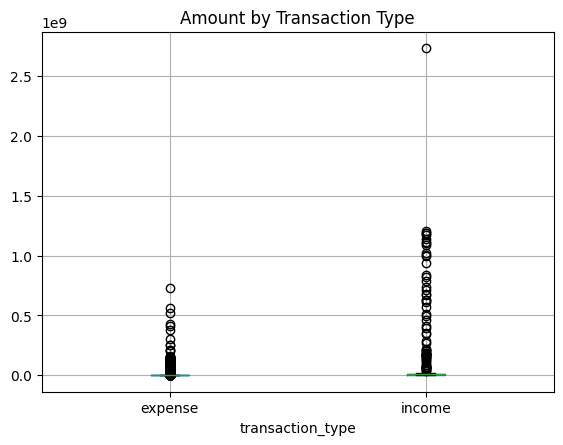

In [33]:
#Cek sebaran data pada amount_idr berdasarkan transaction_type menggunakan boxplot
df_finance.boxplot(column='amount_idr', by='transaction_type')
plt.title("Amount by Transaction Type")
plt.suptitle("")
plt.show()

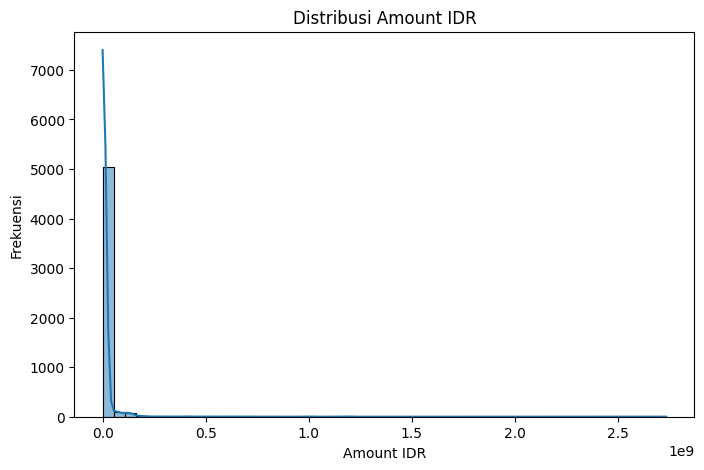

In [34]:
#Membuat histogram distribusi amount_idr
plt.figure(figsize=(8,5))

sns.histplot(
    df_finance['amount_idr'],
    bins=50,
    kde=True
)

plt.title("Distribusi Amount IDR")
plt.xlabel("Amount IDR")
plt.ylabel("Frekuensi")
plt.show()

**Insight:**

- Histogram menunjukkan bahwa distribusi amount_idr bersifat right-skewed, di mana sebagian besar transaksi memiliki nominal yang relatif kecil dan terkonsentrasi pada nilai rendah.
- Terdapat ekor distribusi yang sangat panjang di sisi kanan grafik, yang menunjukkan adanya sejumlah kecil transaksi dengan nominal sangat besar dibandingkan mayoritas transaksi lainnya.
- Pola ini mengindikasikan bahwa data transaksi tidak terdistribusi normal dan dipengaruhi oleh keberadaan transaksi ekstrem (outlier), sehingga rata-rata (mean) kemungkinan lebih tinggi dibandingkan median.
- Distribusi yang sangat miring ke kanan juga menunjukkan adanya ketidakseimbangan skala data, di mana sebagian besar transaksi berada pada rentang nominal rendah, sementara hanya sedikit transaksi yang memiliki nilai sangat tinggi hingga mencapai miliaran rupiah.

In [35]:
df_finance.sort_values(
    by='amount_idr',
    ascending=False
)[
    ['date', 'category', 'transaction_type','amount','currency','amount_idr']
].head(20)

,date,category,transaction_type,amount,currency,amount_idr
2482,2022-12-21,freelance,income,184818.0,USD,2.735306e+09
1607,2024-02-10,bonus,income,75823.0,USD,1.205586e+09
4475,2024-10-14,other,income,74866.0,USD,1.190369e+09
4752,2023-05-12,freelance,income,78210.0,USD,1.188792e+09
9822,2022-08-18,investment,income,79300.0,USD,1.173640e+09
12558,2021-05-24,freelance,income,79605.0,USD,1.138352e+09
9862,2024-02-05,salary,income,69864.0,USD,1.110838e+09
1035,2022-05-20,other,income,74525.0,USD,1.102970e+09
2110,2024-11-09,investment,income,68676.0,USD,1.091948e+09
7838,2024-03-11,investment,income,64156.0,USD,1.020080e+09


In [36]:
df_finance[
    df_finance['transaction_type'] == 'expense'
]['amount_idr'].describe()

,amount_idr
count,4.455000e+03
mean,5.817633e+06
std,2.779472e+07
min,1.071600e+04
25%,4.759775e+05
50%,9.636800e+05
75%,1.554105e+06
max,7.309868e+08


In [37]:
df_finance[
    df_finance['transaction_type'] == 'income'
]['amount_idr'].describe()

,amount_idr
count,7.990000e+02
mean,4.724741e+07
std,1.868710e+08
min,1.884136e+06
25%,5.499116e+06
50%,9.223092e+06
75%,1.280172e+07
max,2.735306e+09


**Insight:**

- Sebaran data pada variabel amount_idr sangat bervariasi, hal ini disebabkan oleh transaksi bernilai sangat besar, terutama income dalam mata uang USD setelah konversi ke rupiah.
- Setelah proses cleaning dan currency conversion, masih terdapat beberapa transaksi bernilai tinggi, terutama pada kategori income seperti freelance, investment, salary, dan bonus dalam mata uang USD. Transaksi tersebut dipertahankan karena masih realistis dalam konteks dataset personal finance dan dianggap sebagai high-value transactions, bukan error data.

In [38]:
df_clean = df_finance.copy()
df_indonesia = df_clean.copy()

In [39]:
#Mapping lokasi India ke Indonesia
location_map = {
    'mumbai': 'jakarta',
    'delhi': 'surabaya',
    'bengaluru': 'bandung',
    'chennai': 'medan',
    'kolkata': 'makassar',
    'hyderabad': 'yogyakarta',
    'pune': 'semarang',
    'jaipur': 'denpasar',
    'lucknow': 'palembang',
    'ahmedabad': 'balikpapan',
    'unknown': 'unknown'
}

#Mengganti nama lokasi menjadi kota di Indonesia
df_indonesia ['location'] = (
    df_indonesia ['location']
    .str.lower()
    .replace(location_map)
)

In [40]:
#Mapping metode pembayaran Indonesia
payment_map = {
    'upi': 'qris',
    'cash': 'tunai',
    'card': 'kartu',
    'bank transfer': 'transfer_bank',
    'unknown': 'ewallet'
}

#Mengganti metode pembayaran
df_indonesia['payment_mode'] = (
    df_indonesia['payment_mode']
    .str.lower()
    .replace(payment_map)
)

In [41]:
#Mapping kategori transaksi
category_map = {
    'food': 'makanan',
    'rent': 'tempat_tinggal',
    'utilities': 'tagihan',
    'travel': 'transportasi',
    'health': 'kesehatan',
    'education': 'pendidikan',
    'entertainment': 'hiburan',
    'salary': 'gaji',
    'freelance': 'freelance',
    'investment': 'investasi',
    'savings': 'tabungan',
    'other': 'lainnya'
}

#Mengganti nama kategori
df_indonesia['category'] = (
    df_indonesia['category']
    .str.lower()
    .replace(category_map)
)

In [42]:
#Mapping notes berdasarkan kategori
notes_dict = {

    #Expense
    'makanan': [
        'makan siang',
        'makan malam',
        'sarapan',
        'ngopi di kafe',
        'pesan gofood',
        'pesan grabfood',
        'pesan shopeefood',
        'beli cemilan',
        'makan di restoran',
        'beli air minum',
        'jajan minimarket'
    ],

    'transportasi': [
        'naik gojek',
        'naik grab',
        'isi bensin',
        'bayar parkir',
        'naik KRL',
        'naik MRT',
        'servis motor',
        'bayar tol'
    ],

    'tempat_tinggal': [
        'bayar kos',
        'bayar kontrakan',
        'bayar sewa rumah',
        'bayar apartemen',
        'iuran kebersihan'
    ],

    'kesehatan': [
        'beli obat',
        'kontrol dokter',
        'tes kesehatan',
        'beli vitamin',
        'bayar rumah sakit',
        'konsultasi kesehatan'
    ],

    'hiburan': [
        'nonton bioskop',
        'langganan Netflix',
        'main game',
        'beli tiket konser',
        'liburan akhir pekan',
        'streaming musik'
    ],

    'pendidikan': [
        'bayar kursus',
        'beli buku',
        'bayar UKT',
        'les online',
        'pelatihan online',
        'beli alat tulis'
    ],

    'tagihan': [
        'bayar listrik',
        'bayar internet',
        'bayar air',
        'bayar BPJS',
        'bayar pulsa',
        'bayar WiFi'
    ],

    'tabungan': [
        'transfer tabungan',
        'menabung bulanan',
        'simpan dana darurat',
        'tabungan masa depan'
    ],

    'lainnya': [
        'keperluan pribadi',
        'pengeluaran lainnya',
        'belanja kebutuhan',
        'transaksi harian'
    ],

    #Income
    'gaji': [
        'gaji bulanan',
        'transfer payroll',
        'penerimaan gaji',
        'bonus perusahaan'
    ],

    'freelance': [
        'bayaran freelance',
        'project desain',
        'project website',
        'jasa konsultasi',
        'pendapatan project'
    ],

    'investasi': [
        'keuntungan investasi',
        'return saham',
        'dividen investasi',
        'profit reksa dana',
        'keuntungan crypto'
    ]
}

#Function membuat notes otomatis
def generate_notes(category):

    if category in notes_dict:
        return random.choice(notes_dict[category])

    return 'transaksi'

#Mengganti notes menjadi Bahasa Indonesia
df_indonesia['notes'] = (
    df_indonesia['category']
    .apply(generate_notes)
)

df_indonesia[['category', 'notes']].head()

,category,notes
14210,freelance,project website
5429,tempat_tinggal,iuran kebersihan
4152,tempat_tinggal,bayar sewa rumah
13768,makanan,makan di restoran
10117,pendidikan,beli alat tulis


In [43]:
df_indonesia.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,amount_raw,currency,year,amount_idr
14210,T0565,U052,2021-01-01,income,freelance,76296.0,tunai,bandung,project website,2021-01,1.0,Friday,False,76296,INR,2021.0,14725128.0
5429,T2465,U098,2021-01-01,expense,tempat_tinggal,12502.0,tunai,bandung,iuran kebersihan,2021-01,1.0,Friday,False,12502,INR,2021.0,2412886.0
4152,T2971,U138,2021-01-01,expense,tempat_tinggal,1575.0,bank_transfer,palembang,bayar sewa rumah,2021-01,1.0,Friday,False,₹1575,INR,2021.0,303975.0
13768,T12231,U123,2021-01-01,expense,makanan,3346.0,bank_transfer,jakarta,makan di restoran,2021-01,1.0,Friday,False,3346,INR,2021.0,645778.0
10117,T1657,U023,2021-01-02,expense,pendidikan,2601.0,kartu,palembang,beli alat tulis,2021-01,1.0,Saturday,True,2601,INR,2021.0,501993.0


In [44]:
#Menyesuaikan nominal rupiah
df_indonesia['amount_idr'] = (
    df_indonesia['amount_idr'] / 100
)

## Exploratory Data Analysis (EDA)

In [45]:
#Cek struktur data
df_indonesia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5254 entries, 14210 to 10159
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    5254 non-null   object        
 1   user_id           5254 non-null   object        
 2   date              5254 non-null   datetime64[ns]
 3   transaction_type  5254 non-null   object        
 4   category          5254 non-null   object        
 5   amount            5254 non-null   float64       
 6   payment_mode      5254 non-null   object        
 7   location          5254 non-null   object        
 8   notes             5254 non-null   object        
 9   year_month        5254 non-null   period[M]     
 10  month             5254 non-null   float64       
 11  day_of_week       5254 non-null   object        
 12  is_weekend        5254 non-null   bool          
 13  amount_raw        5254 non-null   object        
 14  currency          5254 n

In [46]:
#Cek statistik deskriptif
df_indonesia.describe(include="all")

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,amount_raw,currency,year,amount_idr
count,5254,5254,5254,5254,5254,5254.000000,5254,5254,5254,5254,5254.000000,5254,5254,5254,5254,5254.000000,5.254000e+03
unique,5254,150,NaN,2,13,NaN,5,11,71,48,NaN,7,2,4682,2,NaN,NaN
top,T1955,U036,NaN,expense,makanan,NaN,qris,surabaya,bayar kos,2024-09,NaN,Saturday,False,-500,INR,NaN,NaN
freq,1,55,NaN,4455,1144,NaN,1260,518,196,131,NaN,771,3722,26,4978,NaN,NaN
mean,NaN,NaN,2023-01-12 08:29:46.981347584,NaN,NaN,14985.225352,NaN,NaN,NaN,NaN,6.547583,NaN,NaN,NaN,NaN,2022.530072,1.211805e+05
min,NaN,NaN,2021-01-01 00:00:00,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2021.000000,1.071600e+02
25%,NaN,NaN,2022-01-06 00:00:00,NaN,NaN,2832.750000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,2022.000000,5.622795e+03
50%,NaN,NaN,2023-01-21 00:00:00,NaN,NaN,5927.500000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,2023.000000,1.187844e+04
75%,NaN,NaN,2024-01-12 00:00:00,NaN,NaN,9379.000000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,2024.000000,1.940558e+04
max,NaN,NaN,2024-12-31 00:00:00,NaN,NaN,978324.000000,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,2024.000000,2.735306e+07


In [47]:
#Cek 5 data teratas
df_indonesia.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,amount_raw,currency,year,amount_idr
14210,T0565,U052,2021-01-01,income,freelance,76296.0,tunai,bandung,project website,2021-01,1.0,Friday,False,76296,INR,2021.0,147251.28
5429,T2465,U098,2021-01-01,expense,tempat_tinggal,12502.0,tunai,bandung,iuran kebersihan,2021-01,1.0,Friday,False,12502,INR,2021.0,24128.86
4152,T2971,U138,2021-01-01,expense,tempat_tinggal,1575.0,bank_transfer,palembang,bayar sewa rumah,2021-01,1.0,Friday,False,₹1575,INR,2021.0,3039.75
13768,T12231,U123,2021-01-01,expense,makanan,3346.0,bank_transfer,jakarta,makan di restoran,2021-01,1.0,Friday,False,3346,INR,2021.0,6457.78
10117,T1657,U023,2021-01-02,expense,pendidikan,2601.0,kartu,palembang,beli alat tulis,2021-01,1.0,Saturday,True,2601,INR,2021.0,5019.93


In [48]:
#Distribusi transaksi per category
df_indonesia.groupby("category")["transaction_id"].count().sort_values(ascending=False)

,transaction_id
category,
makanan,1144
tempat_tinggal,875
transportasi,667
tagihan,529
hiburan,455
pendidikan,337
lainnya,269
kesehatan,221
investasi,162


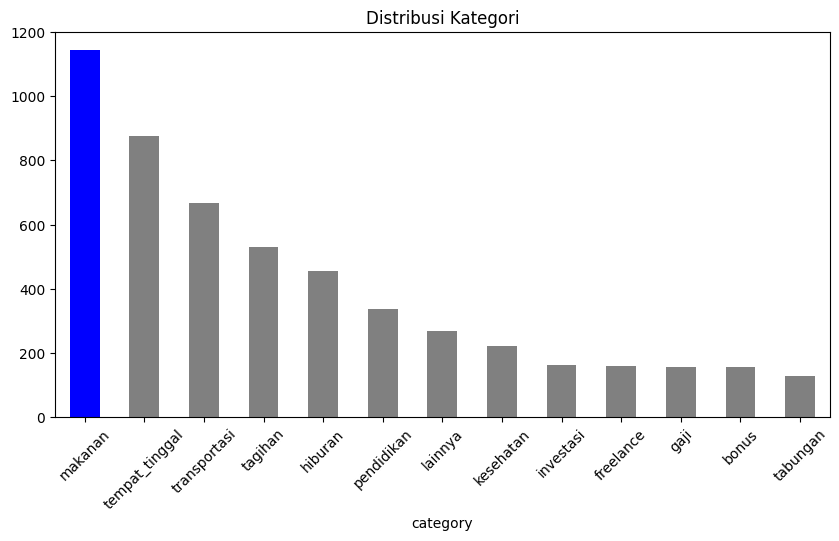

In [49]:
#Distribusi category
cat_counts = df_indonesia["category"].value_counts()

colors = ["gray"] * len(cat_counts)
colors[0] = "blue"

cat_counts.plot(kind="bar", color=colors, figsize=(10,5))
plt.title("Distribusi Kategori")
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Berdasarkan hasil pengelompokan data, kategori makanan memiliki jumlah transaksi tertinggi (114 transaksi), diikuti oleh tempat_tinggal (875 transaksi) dan transportasi (667 transaksi). Hal ini menunjukkan bahwa transaksi didominasi oleh kategori kebutuhan utama dan aktivitas rutin. Sementara itu, kategori lain seperti gaji, bonus, dan tabungan memiliki jumlah transaksi yang relatif lebih rendah, sehingga kontribusinya terhadap total transaksi tidak terlalu signifikan.

In [50]:
#Distribusi payment_mode
df_indonesia["payment_mode"].value_counts()

,count
payment_mode,
qris,1260
tunai,1248
bank_transfer,1244
kartu,1231
ewallet,271


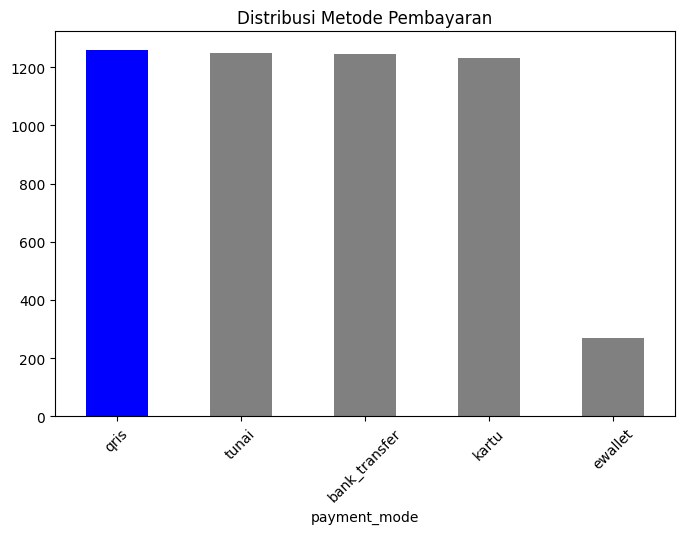

In [51]:
pay_counts = df_indonesia["payment_mode"].value_counts()

colors = ["gray"] * len(pay_counts)
colors[0] = "blue"

pay_counts.plot(kind="bar", color=colors, figsize=(8,5))
plt.title("Distribusi Metode Pembayaran")
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Berdasarkan hasil tersebut, dapat dilihat bahwa metode pembayaran qris, tunai, dan bank transfer memiliki jumlah transaksi yang hampir seimbang, dengan qris sedikit lebih tinggi dibandingkan metode lainnya. Hal ini menunjukkan bahwa penggunaan metode pembayaran dalam transaksi cukup merata dan tidak didominasi secara signifikan oleh satu metode saja.

In [52]:
df_indonesia["location"].value_counts()

,count
location,
surabaya,518
semarang,516
makassar,505
bandung,503
medan,484
jakarta,466
yogyakarta,465
balikpapan,464
denpasar,449


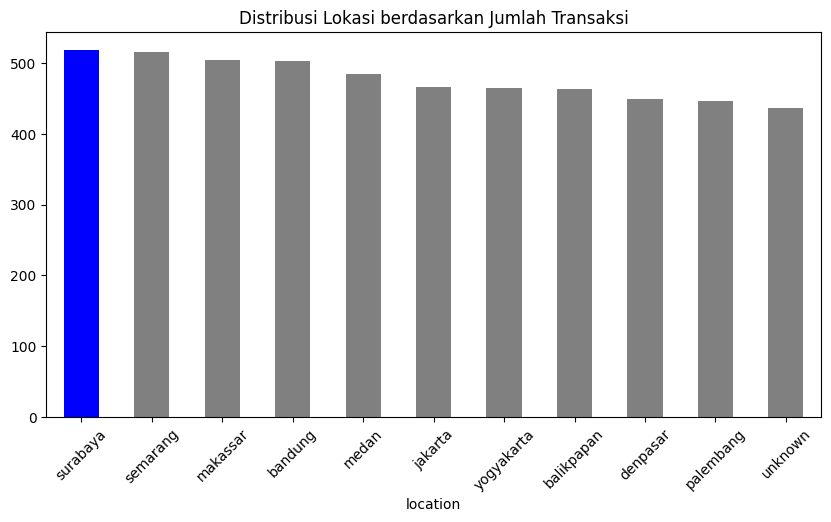

In [53]:
#Distribusi Location
loc_counts = df_indonesia["location"].value_counts()

colors = ["gray"] * len(loc_counts)
colors[0] = "blue"

loc_counts.plot(kind="bar", color=colors, figsize=(10,5))
plt.xticks(rotation=45)
plt.title("Distribusi Lokasi berdasarkan Jumlah Transaksi")
plt.show()

**Insight:**
- Berdasarkan hasil tersebut, dapat dilihat bahwa jumlah transaksi pada setiap lokasi relatif merata, dengan surabaya memiliki jumlah transaksi tertinggi yaitu 518 transaksi, diikuti oleh semarang berjumlah 516 transaksi, dan makassar berjumlah 505 transaksi. Hal ini menunjukkan bahwa aktivitas transaksi tersebar di berbagai lokasi tanpa perbedaan yang terlalu signifikan.

###**EDA untuk pertanyaan 1**

In [54]:
#Membuat kolom periode bulanan
df_indonesia['year_month'] = df_indonesia['date'].dt.to_period('M')

#Mengelompokkan income dan expense
income_expense = df_indonesia.groupby(
    ['year_month', 'transaction_type']
)['amount_idr'].sum().unstack().fillna(0)

In [55]:
#Mengubah semua nama kolom menjadi huruf kecil
income_expense = income_expense.rename(columns=str.lower)

#Mengambil kolom income dan expense, jika tidak ada dibuat kolom dengan nilai 0
income_expense['income'] = income_expense.get('income', 0)
income_expense['expense'] = income_expense.get('expense', 0)

In [56]:
#Menghitung selisih antara expense dan income
income_expense['cashflow'] = income_expense['income'] - income_expense['expense']

#Menghitung rasio pengeluaran
income_expense['expense_ratio'] = income_expense['expense'] / income_expense['income'].replace(0, 1)

###**EDA untuk pertanyaan 2**

In [57]:
#Mengambil data expense
df_indonesia['transaction_type'] = df_indonesia['transaction_type'].str.lower().str.strip()
df_expense = df_indonesia[df_indonesia['transaction_type'] == 'expense'].copy()

#Kolom year_month
df_expense['year_month'] = df_expense['date'].dt.to_period('M')

#Agregasi total pengeluaran perbulan
category_monthly = df_expense.groupby(
    ['year_month','category']
)['amount_idr'].sum().reset_index()

###**EDA untuk pertanyaan 3**

In [58]:
#Mengambil tahun dari date
df_indonesia['year'] = df_indonesia['date'].dt.year

#Membuat tabel ringkasan
yearly_cashflow = df_indonesia.pivot_table(
    index=['user_id','year'],
    columns='transaction_type',
    values='amount_idr',
    aggfunc='sum'
)

#Mengisi nilai kosong dengan 0
yearly_cashflow = yearly_cashflow.fillna(0)

#Hitung cashflow
yearly_cashflow['cashflow'] = yearly_cashflow['income'] - yearly_cashflow['expense']

#Ambil user top 5 per tahun dengan cashflow negatif
top_deficit = (
    yearly_cashflow[yearly_cashflow['cashflow'] < 0]
    .sort_values(['year', 'cashflow'])
    .groupby('year')
    .head(5)
)

top_deficit.reset_index()

transaction_type,user_id,year,expense,income,cashflow
0,U138,2021,4922999.30,334934.13,-4588065.17
1,U034,2021,4343215.78,222511.63,-4120704.15
2,U113,2021,3921418.50,52893.58,-3868524.92
3,U033,2021,3630148.98,149397.44,-3480751.54
4,U115,2021,2254249.71,52011.57,-2202238.14
5,U088,2022,6391352.84,97908.52,-6293444.32
6,U147,2022,7373107.44,1241476.80,-6131630.64
7,U060,2022,2304244.44,34661.56,-2269582.88
8,U051,2022,2237887.68,125552.04,-2112335.64
9,U115,2022,2075779.16,47956.92,-2027822.24


###**EDA untuk pertanyaan 4**

In [59]:
payment_usage = df_expense.groupby('payment_mode')['amount_idr'].sum().sort_values(ascending=False)

###**EDA untuk pertanyaan 5**

In [60]:
#Mengambil pengeluaran dari 25% terbesar
threshold = df_expense["amount_idr"].quantile(0.75)

#Membuat kolom high_spending dengan nilai 0 dan 1
df_expense["high_spending"] = (df_expense["amount_idr"] >= threshold).astype(int)

In [61]:
high_spending = df_expense[df_expense['high_spending'] == 1]
high_spending_time = high_spending.groupby('year_month')['amount_idr'].count()

##**Visualisasi Data**

###**Pertanyaan 1:** Bagaimana tren perbandingan antara income dan expense pengguna per bulan selama periode Januari 2021 hingga Desember 2024, serta pada bulan apa pengeluaran melebihi pemasukan?

In [62]:
income_expense.index = income_expense.index.to_timestamp()
income_expense[income_expense['cashflow'] < 0]

transaction_type,expense,income,cashflow,expense_ratio
year_month,,,,
2021-02-01,10795296.02,1544459.34,-9250836.68,6.989693
2021-03-01,6054523.64,1123296.67,-4931226.97,5.389960
2021-04-01,6128300.25,3049156.38,-3079143.87,2.009835
2021-09-01,10960349.70,1529851.17,-9430498.53,7.164324
2021-10-01,9509460.22,2000321.48,-7509138.74,4.753966
2021-12-01,3810235.46,2748194.55,-1062040.91,1.386450
2022-01-01,2828118.12,1427796.08,-1400322.04,1.980758
2022-02-01,7616220.40,1198627.84,-6417592.56,6.354116
2022-03-01,7365474.48,832717.80,-6532756.68,8.845103


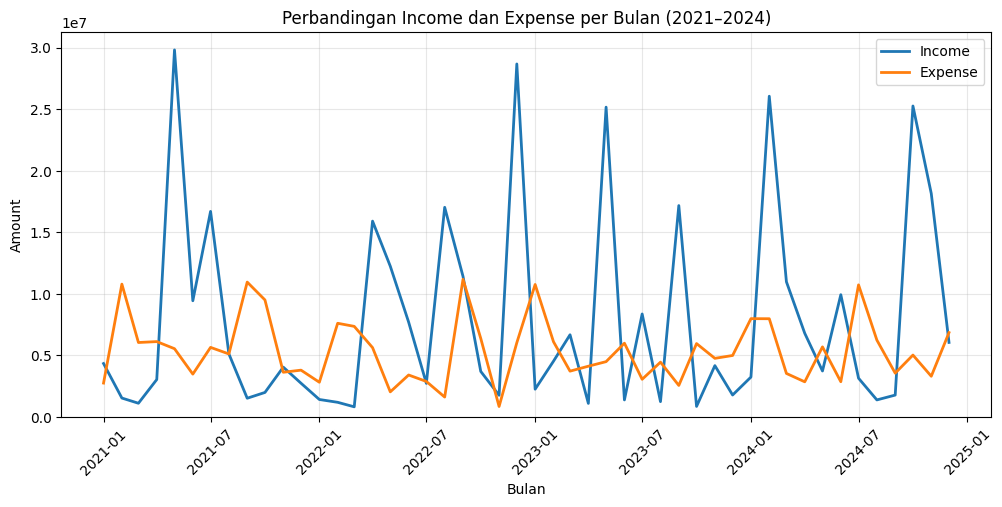

In [63]:
plt.figure(figsize=(12,5))

plt.plot(income_expense.index, income_expense['income'], label='Income', linewidth=2)
plt.plot(income_expense.index, income_expense['expense'], label='Expense', linewidth=2)

plt.title("Perbandingan Income dan Expense per Bulan (2021–2024)")
plt.xlabel("Bulan")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.ylim(bottom=0)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

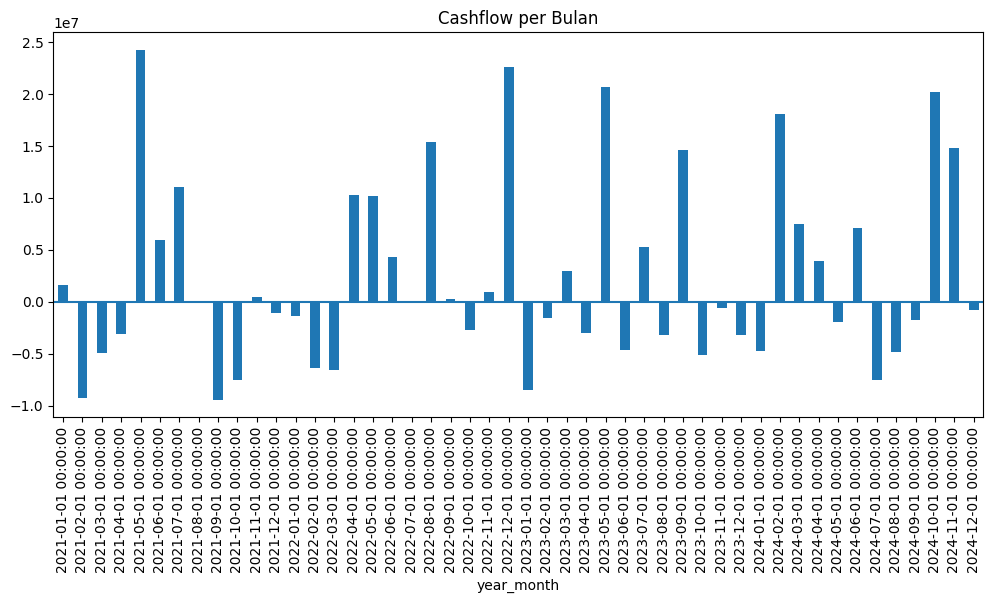

In [64]:
income_expense['cashflow'].plot(kind='bar', figsize=(12,5))
plt.title("Cashflow per Bulan")
plt.axhline(0)
plt.show()

**Insight:**
- Grafik menunjukkan bahwa baik income maupun expense mengalami fluktuasi sepanjang periode 2021-2024, yang mengindikasikan bahwa kondisi keuangan tidak stabil dan dipengaruhi oleh variasi transaksi setiap bulan.
- Pada beberapa periode, garis expense berada di atas income, yang menunjukkan terjadinya defisit (pengeluaran lebih besar dari pemasukan). Berdasarkan hasil analisis, kondisi defisit terjadi pada:
1. Tahun 2021: Februari, Maret, April, September, Oktober, dan Desember
2. Tahun 2022: Januari, Februari, Maret, Juli, dan Oktober
3. Tahun 2023: Januari, Februari, April, Juni, Agustus, Oktober, November, dan Desember
4. Tahun 2024: Januari, Mei, Juli, Agustus, September, dan Desember
- Income terlihat lebih fluktuatif dibandingkan expense, dengan beberapa lonjakan signifikan pada periode tertentu. Sementara itu, expense juga mengalami perubahan dari waktu ke waktu, namun relatif lebih konsisten dibandingkan income.
- Cashflow bulanan menunjukkan fluktuasi yang cukup besar, dengan beberapa bulan mengalami surplus dan beberapa bulan lainnya mengalami defisit hingga ratusan juta rupiah. Hal ini menunjukkan bahwa kondisi keuangan belum stabil karena masih terdapat periode ketika pengeluaran melebihi pemasukan.

###**Pertanyaan 2:** Bagaimana distribusi persentase pengeluaran berdasarkan kategori setiap bulan selama periode Januari 2021 hingga Desember 2024, dan kategori apa yang secara konsisten menjadi penyumbang terbesar?

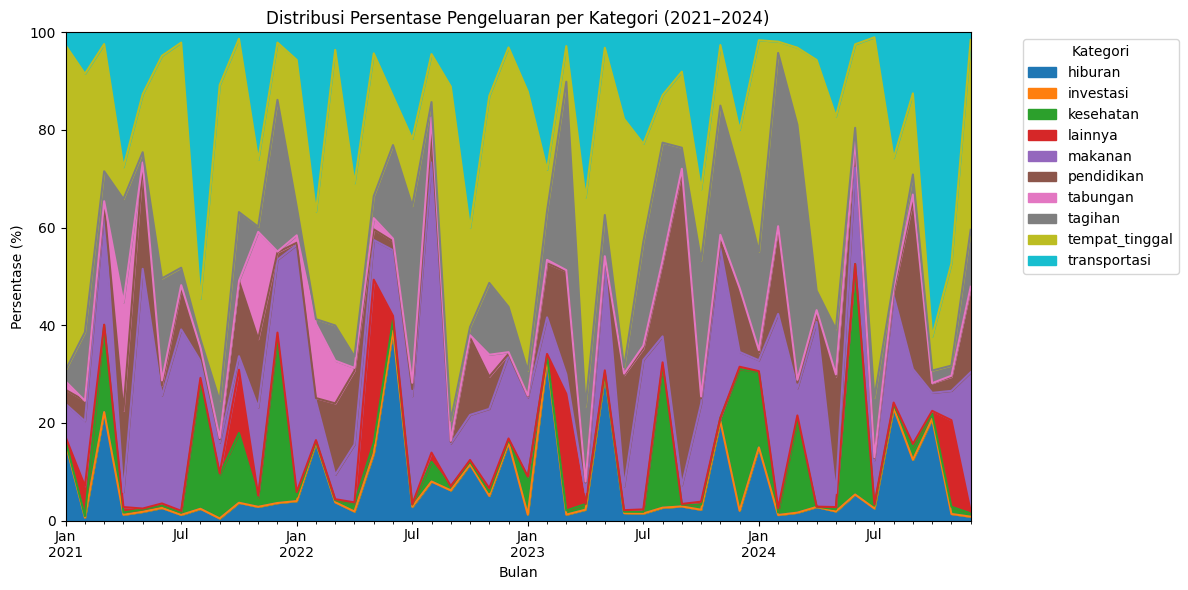

,0
category,
tempat_tinggal,29.397749
makanan,16.188666
transportasi,15.042557
tagihan,12.466393
pendidikan,8.743660
hiburan,7.806313
kesehatan,5.880612
lainnya,2.366650
tabungan,2.106288


In [65]:
#Membuat pivot berdasarkan year_month, category, dan amount
category_pivot = category_monthly.pivot(
    index='year_month',
    columns='category',
    values='amount_idr'
).fillna(0)

category_presentase = category_pivot.div(category_pivot.sum(axis=1), axis=0) * 100

category_presentase.plot(
    kind='area',
    stacked=True,
    figsize=(12,6)
)

plt.title("Distribusi Persentase Pengeluaran per Kategori (2021–2024)")
plt.xlabel("Bulan")
plt.ylabel("Persentase (%)")
plt.legend(title="Kategori", bbox_to_anchor=(1.05,1))
plt.ylim(0,100)
plt.tight_layout()
plt.show()

#Rata-rata presentase pengeluaran per category
category_presentase.mean().sort_values(ascending=False)

**Insight:**
- Berdasarkan analisis distribusi persentase pengeluaran, kategori tempat_tinggal menjadi kontributor terbesar secara konsisten sepanjang periode 2021-2024, dengan rata-rata kontribusi sekitar 29.40% terhadap total pengeluaran bulanan.
- Kategori terbesar berikutnya adalah makanan sebesar 16.19%, yang menunjukkan bahwa kebutuhan konsumsi harian merupakan salah satu komponen utama dalam pola pengeluaran pengguna.
- Selain itu, kategori seperti transportasi (15.04%), tagihan (12.47%), pendidikan (8.74%), dan hiburan (7.81%) memberikan kontribusi menengah terhadap total pengeluaran. Hal ini mencerminkan kombinasi antara kebutuhan rutin dan pengeluaran terkait gaya hidup.
- Sementara itu, kategori kesehatan memiliki kontribusi yang relatif kecil, yaitu sekitar 5.88%, sedangkan kategori tabungan (2.11%) dan investasi (0.001%) menunjukkan proporsi yang sangat rendah terhadap total pengeluaran selama periode pengamatan.
- Secara keseluruhan, distribusi pengeluaran antar kategori cenderung relatif stabil dari waktu ke waktu, dengan kategori tempat_tinggal yang secara konsisten mendominasi pengeluaran bulanan pada hampir setiap periode.

### **Pertanyaan 3:** Sejauh mana setiap user_id mengalami kondisi defisit (cashflow negatif) selama periode Januari 2021 hingga Desember 2024, berdasarkan selisih total income dan expense, dan berapa proporsi user yang mengalami kondisi tersebut?

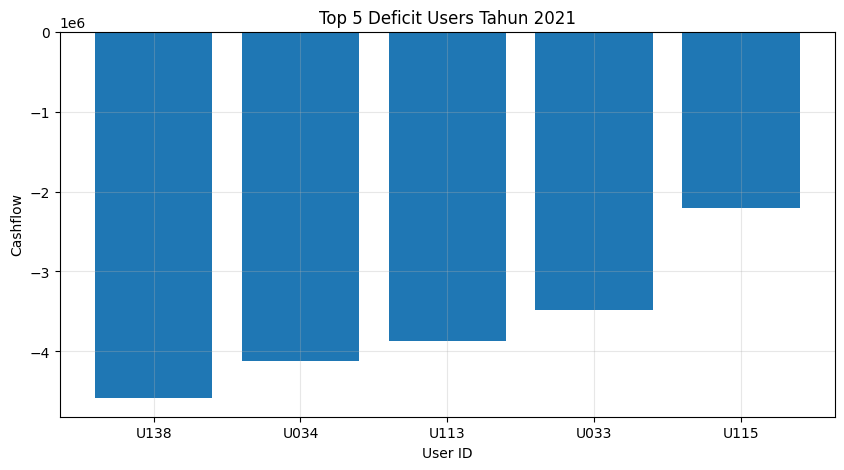

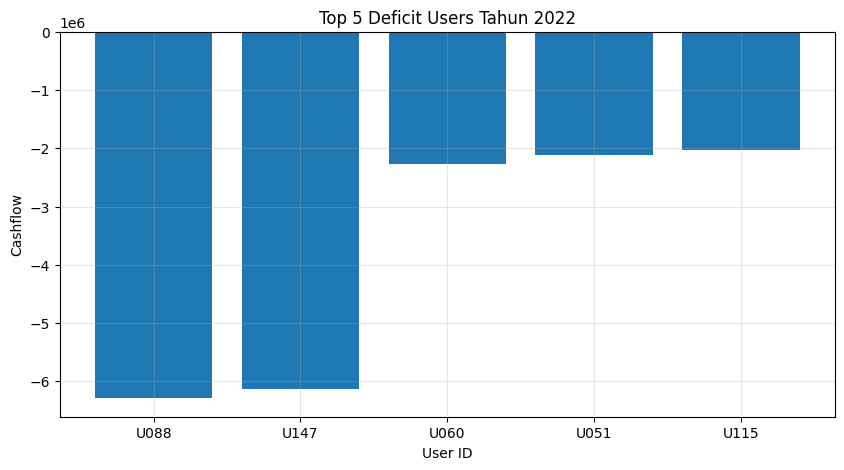

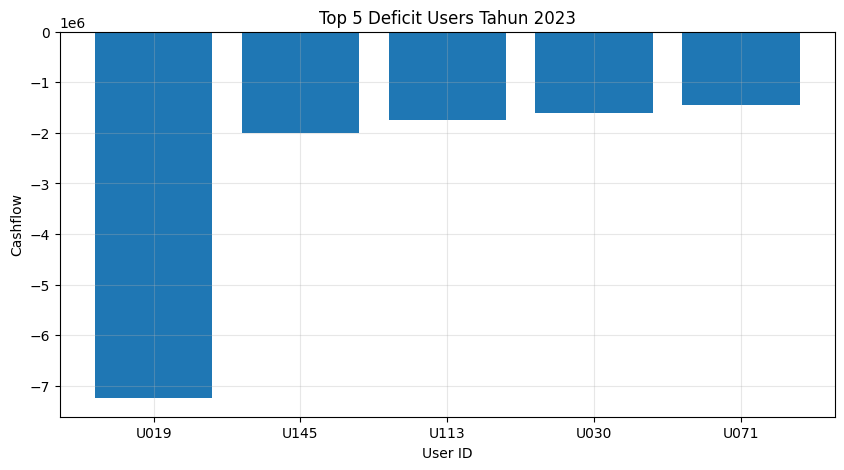

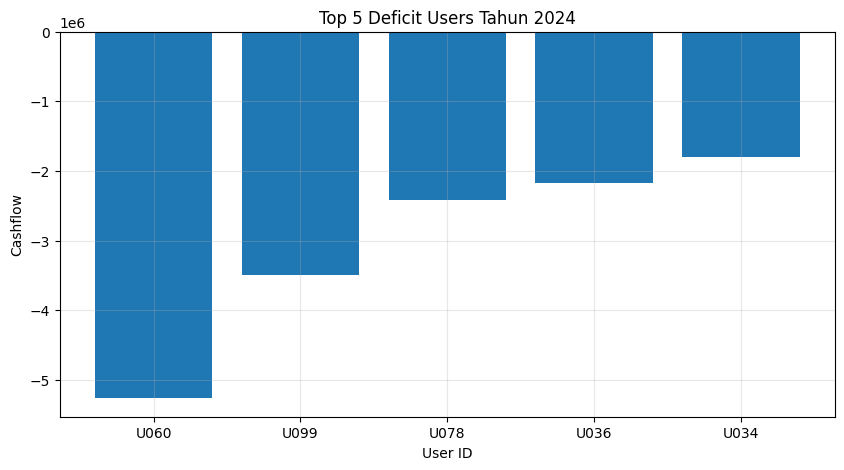

In [66]:
#Menentukan top 5 pengguna dengan cashflow negatif terbesar setiap tahun
top_deficit = (
    yearly_cashflow
    .reset_index()
    .query('cashflow < 0')
    .sort_values(['year', 'cashflow'])
    .groupby('year')
    .head(5)
)

for year, temp in top_deficit.groupby('year'):
    plt.figure(figsize=(10,5))

    plt.bar(temp['user_id'], temp['cashflow'])

    plt.title(f"Top 5 Deficit Users Tahun {year}")
    plt.xlabel("User ID")
    plt.ylabel("Cashflow")

    plt.xticks(rotation=0)
    plt.grid(alpha=0.3)

    plt.show()

In [67]:
#Proporsi pengguna yang deficit per tahun
df_reset = yearly_cashflow.reset_index()
result = (
    df_reset
    .groupby('year')
    .agg(
        total_user=('user_id', 'nunique'),
        deficit_user=('cashflow', lambda x: (x < 0).sum())
    )
)

#Hitung presentase
result['proporsi_deficit (%)'] = (result['deficit_user'] / result['total_user']) * 100

result.reset_index()

,year,total_user,deficit_user,proporsi_deficit (%)
0,2021,150,93,62.000000
1,2022,150,81,54.000000
2,2023,150,93,62.000000
3,2024,150,80,53.333333


**Insight:**
- Berdasarkan analisis cashflow per user pada periode 2021-2024, seluruh user yang termasuk dalam kelompok top deficit users memiliki cashflow negatif, yang menunjukkan bahwa total pengeluaran (expense) lebih besar dibandingkan total pemasukan (income) pada tahun tersebut.
- Nilai defisit yang dialami user cenderung berada pada skala ratusan ribu rupiah. Pada tahun 2021, defisit terbesar dialami oleh user U138 dengan nilai sekitar -460 ribu rupiah. Pada tahun 2022, defisit terbesar meningkat menjadi sekitar -630 ribu rupiah yang dialami oleh user U088. Kondisi paling ekstrem terjadi pada tahun 2023, di mana user U019 mengalami defisit hingga sekitar -720 ribu rupiah. Sementara itu, pada tahun 2024, defisit terbesar tercatat sekitar -530 ribu rupiah pada user U060.
- Secara umum, tingkat defisit antar user menunjukkan fluktuasi dari tahun ke tahun dan tidak membentuk pola peningkatan yang konsisten. Meskipun tahun 2023 menunjukkan defisit paling besar, pada tahun 2024 nilai defisit tertinggi justru menurun dibandingkan tahun sebelumnya.
- Selain itu, terdapat beberapa user yang muncul lebih dari satu kali pada periode berbeda, seperti U034, U060, U113, dan U115. Hal ini menunjukkan bahwa beberapa user mengalami kondisi defisit secara berulang pada lebih dari satu tahun pengamatan.
- Berdasarkan analisis proporsi user defisit per tahun, persentase user yang mengalami cashflow negatif tergolong cukup tinggi dan relatif stabil selama periode 2021-2024. Pada tahun 2021 dan 2023, proporsi user defisit mencapai 62% dari total user. Sementara itu, tahun 2022 dan 2024 menunjukkan proporsi yang sedikit lebih rendah, masing-masing sebesar 54% dan 53.33%.
- Secara keseluruhan, hasil analisis menunjukkan bahwa lebih dari separuh user mengalami kondisi defisit pada setiap tahun pengamatan, yang mengindikasikan bahwa ketidakseimbangan antara pemasukan dan pengeluaran merupakan pola yang cukup umum dalam dataset ini.

### **Pertanyaan 4:** Metode pembayaran apa yang paling sering digunakan selama periode Januari 2021 hingga Desember 2024, serta bagaimana kontribusinya terhadap total dan rata-rata nilai transaksi?


In [68]:
payment_summary = pd.DataFrame({
    'frequency': df_expense['payment_mode'].value_counts(),
    'total_amount': df_expense.groupby('payment_mode')['amount_idr'].sum(),
    'avg_amount': df_indonesia.groupby('payment_mode')['amount_idr'].mean()
})

payment_summary = payment_summary.sort_values(by='frequency', ascending=False)
payment_summary

,frequency,total_amount,avg_amount
payment_mode,,,
bank_transfer,1066,56865464.99,107763.932460
qris,1061,72720104.03,146434.915460
tunai,1059,55938436.59,100062.937348
kartu,1049,61188595.43,124349.584777
ewallet,220,12462945.56,148203.550443


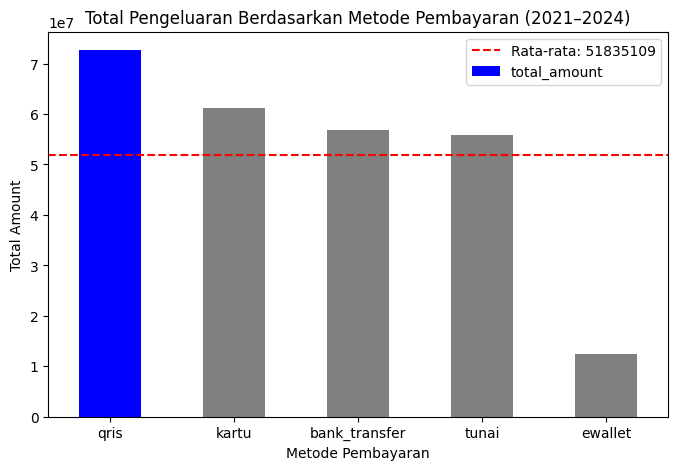

In [69]:
payment_summary = payment_summary.sort_values(by='total_amount', ascending=False)
colors = ["gray"] * len(payment_summary)
colors[0] = "blue"

ax = payment_summary['total_amount'].plot(
    kind='bar',
    figsize=(8,5),
    color=colors
)

avg_total = payment_summary['total_amount'].mean()

plt.axhline(
    y=avg_total,
    color='red',
    linestyle='--',
    label=f'Rata-rata: {avg_total:.0f}')

plt.title("Total Pengeluaran Berdasarkan Metode Pembayaran (2021–2024)")
plt.xlabel("Metode Pembayaran")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.legend()
plt.show()

**Insight:**
- Berdasarkan analisis metode pembayaran selama periode 2021-2024, metode pembayaran qris memiliki total pengeluaran terbesar dibandingkan metode lainnya, dengan total transaksi mencapai sekitar 72,72 juta rupiah dari 1.061 transaksi. Selain frekuensinya tinggi, rata-rata nominal transaksi menggunakan qris juga relatif besar, yaitu sekitar 146 ribu rupiah per transaksi, yang menunjukkan bahwa metode ini menjadi salah satu metode pembayaran digital yang paling dominan digunakan pengguna.

- Metode kartu berada pada posisi berikutnya dengan total pengeluaran sekitar 61,19 juta rupiah dari 1.049 transaksi. Rata-rata nominal transaksi menggunakan kartu mencapai sekitar 124 ribu rupiah per transaksi, yang mengindikasikan bahwa metode ini cenderung digunakan untuk transaksi dengan nominal menengah hingga besar.

- Metode bank_transfer dan tunai memiliki frekuensi penggunaan tertinggi dan relatif seimbang, masing-masing sebanyak 1.066 dan 1.059 transaksi. Namun, rata-rata nominal transaksi keduanya lebih rendah dibandingkan qris dan kartu, yaitu sekitar 107 ribu rupiah untuk bank transfer dan 100 ribu rupiah untuk tunai. Hal ini menunjukkan bahwa kedua metode tersebut lebih sering digunakan untuk transaksi rutin dengan nominal yang relatif lebih kecil.

- Sementara itu, metode ewallet memiliki frekuensi penggunaan paling rendah, yaitu hanya 220 transaksi. Meskipun demikian, rata-rata nominal transaksinya justru menjadi yang tertinggi, yaitu sekitar 148 ribu rupiah per transaksi. Hal ini menunjukkan bahwa ewallet cenderung digunakan pada transaksi dengan nominal yang relatif lebih besar meskipun jumlah penggunaannya tidak terlalu sering.

- Secara keseluruhan, pola penggunaan metode pembayaran selama periode 2021-2024 menunjukkan bahwa pengguna cenderung menyesuaikan metode pembayaran berdasarkan kebutuhan dan nilai transaksi. Metode seperti tunai dan bank transfer lebih sering digunakan untuk transaksi rutin sehari-hari, sedangkan qris, kartu, dan ewallet cenderung digunakan untuk transaksi dengan nominal yang lebih besar.


###**Pertanyaan 5:** Bagaimana pola kemunculan transaksi bernilai tinggi (high spending), yang didefinisikan sebagai transaksi di atas persentil ke-75, berdasarkan waktu selama periode Januari 2021 hingga Desember 2024?

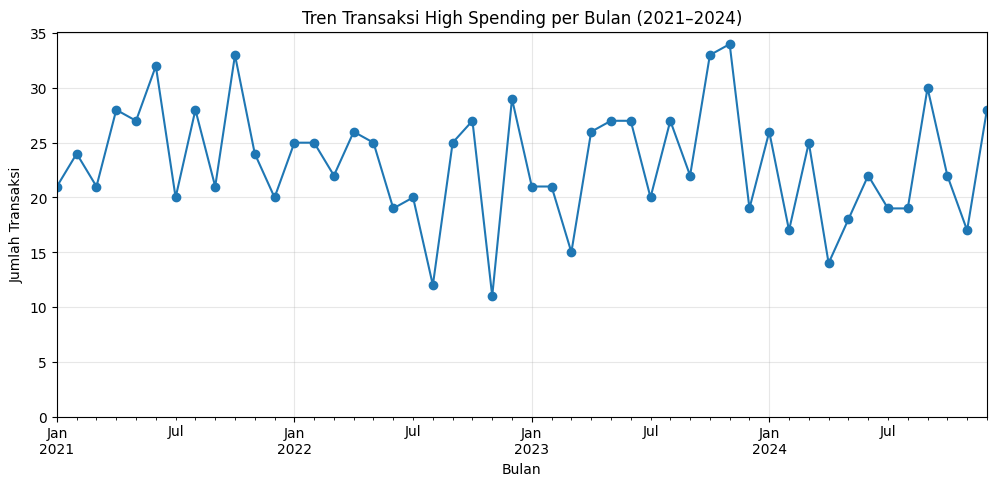

In [70]:
high_spending_time.plot(figsize=(12,5), marker='o')

plt.title("Tren Transaksi High Spending per Bulan (2021–2024)")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=0)
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.show()

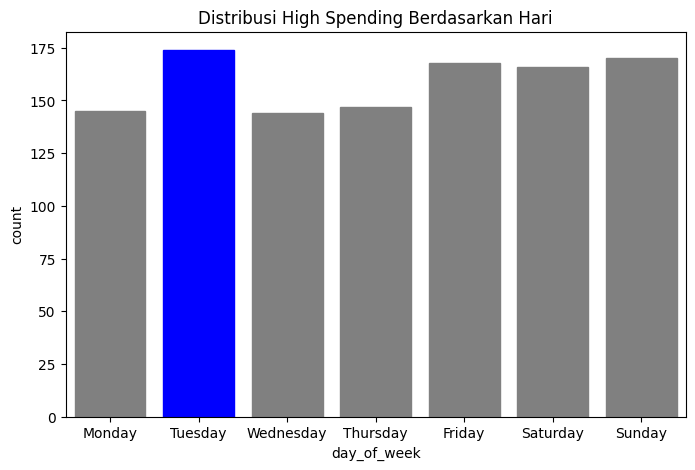

In [71]:
plt.figure(figsize=(8,5))

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ax = sns.countplot(
    data=high_spending,
    x='day_of_week',
    order=order
)

#Ambil index dengan nilai tertinggi
counts_high_spending = high_spending['day_of_week'].value_counts().reindex(order)
max_idx = counts_high_spending.values.argmax()

for i, bar in enumerate(ax.patches):
    if i == max_idx:
        bar.set_color('blue')
    else:
        bar.set_color('gray')

plt.title("Distribusi High Spending Berdasarkan Hari")
plt.xticks(rotation=0)
plt.show()

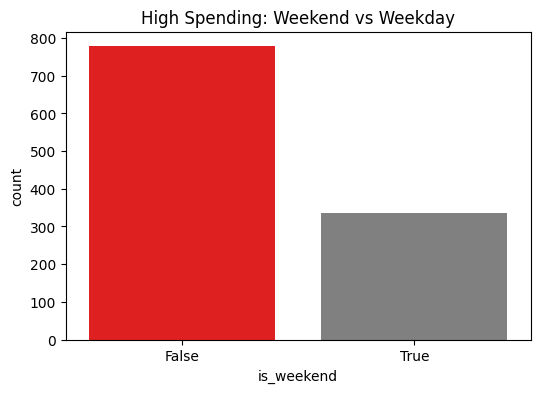

In [72]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=high_spending,
    x='is_weekend',
    hue='is_weekend',
    palette={False: 'red', True: 'gray'},
    legend=False
)

plt.title("High Spending: Weekend vs Weekday")
plt.show()

**Insight:**
- Transaksi high spending terjadi di seluruh hari dalam seminggu dengan distribusi yang relatif merata, meskipun terdapat sedikit peningkatan pada hari tertentu seperti Selasa dan Minggu.
- Mayoritas transaksi high spending justru terjadi pada hari kerja (weekday) dibandingkan akhir pekan (weekend).
- Meskipun akhir pekan sering dianggap dengan aktivitas konsumtif, data menunjukkan bahwa transaksi bernilai tinggi tidak secara signifikan terkonsentrasi pada weekend.

##**Conclusion:**
Berdasarkan hasil analisis data transaksi selama periode Januari 2021 hingga Desember 2024, kondisi keuangan pengguna selama periode 2021-2024 cenderung fluktuatif, terlihat dari perubahan income, expense, dan cashflow setiap bulan. Pada beberapa periode, pengeluaran lebih besar dibandingkan pemasukan sehingga terjadi kondisi defisit, terutama pada beberapa bulan tertentu di setiap tahun pengamatan. Selain itu, cashflow bulanan menunjukkan fluktuasi yang cukup besar dengan beberapa periode mengalami surplus maupun defisit hingga ratusan ribu rupiah.

Dari sisi pengeluaran, kategori tempat_tinggal menjadi kontributor terbesar dalam total pengeluaran bulanan, diikuti oleh kategori makanan. Selain itu, kategori transportasi, tagihan, pendidikan, dan hiburan juga memberikan kontribusi yang cukup signifikan. Secara keseluruhan, distribusi pengeluaran antar kategori cenderung stabil sepanjang periode pengamatan dan menunjukkan bahwa sebagian besar pengeluaran digunakan untuk kebutuhan rutin sehari-hari.

Analisis cashflow per user menunjukkan bahwa seluruh top deficit users mengalami cashflow negatif dengan nilai defisit terbesar berada pada kisaran ratusan ribu rupiah. Defisit paling besar terjadi pada tahun 2023 sekitar -720 ribu rupiah, sedangkan tahun lainnya berada pada kisaran -460 ribu hingga -630 ribu rupiah. Selain itu, lebih dari separuh user mengalami kondisi defisit setiap tahun, yang menunjukkan bahwa ketidakseimbangan antara pemasukan dan

Dalam penggunaan metode pembayaran, qris menjadi metode dengan total pengeluaran terbesar sekaligus memiliki frekuensi transaksi yang tinggi. Sementara itu, tunai dan bank transfer lebih sering digunakan untuk transaksi rutin dengan nominal relatif kecil, sedangkan kartu dan ewallet cenderung digunakan untuk transaksi dengan nominal yang lebih besar. Hal ini menunjukkan bahwa pengguna menyesuaikan metode pembayaran berdasarkan kebutuhan dan nilai transaksi.

Transaksi high spending tersebar relatif merata sepanjang periode 2021-2024 dan tidak menunjukkan pola waktu yang terlalu kuat. Mayoritas transaksi bernilai tinggi juga tetap terjadi pada hari kerja dibandingkan akhir pekan, sehingga pengeluaran besar cenderung lebih dipengaruhi oleh kebutuhan tertentu dibandingkan faktor waktu transaksi.

Secara keseluruhan, pola pengeluaran pengguna selama periode pengamatan lebih banyak dipengaruhi oleh kebutuhan sehari-hari dibandingkan faktor temporal. Kategori seperti tempat_tinggal dan makanan secara konsisten mendominasi pengeluaran, sedangkan transaksi bernilai besar muncul secara sporadis dan tidak menunjukkan pola waktu yang kuat. Hasil ini menunjukkan bahwa karakteristik pengeluaran pengguna lebih mencerminkan kebutuhan finansial rutin dibandingkan perilaku pengeluaran musiman atau berbasis waktu tertentu.

##**Preprocessing model**

In [73]:
#Membuat dataset khusus modeling/aplikasi Indonesia
df_model = df_indonesia.copy()

list(df_model.columns)

['transaction_id',
 'user_id',
 'date',
 'transaction_type',
 'category',
 'amount',
 'payment_mode',
 'location',
 'notes',
 'year_month',
 'month',
 'day_of_week',
 'is_weekend',
 'amount_raw',
 'currency',
 'year',
 'amount_idr']

In [74]:
#Menghapus kolom yang tidak digunakan untuk modeling
df_model = df_model.drop(
    columns=[
        'transaction_id',
        'user_id',
        'notes',
        'amount_raw',
        'date',
        'year_month',
        'currency'
    ]
)

In [75]:
#Melakukan one-hot encoding pada data categorical
df_model = pd.get_dummies(
    df_model,
    columns=[
        'transaction_type',
        'category',
        'payment_mode',
        'location',
        'day_of_week'
    ],
    drop_first=True
)

In [76]:
#Mengubah kolom boolean hasil encoding menjadi integer
bool_cols = df_model.select_dtypes(
    include='bool'
).columns

df_model[bool_cols] = (
    df_model[bool_cols]
    .astype(int)
)

In [77]:
#Membuat scaler untuk Standard Scaling
scaler = StandardScaler()

#Menentukan kolom numerik
numeric_cols = [
    'amount',
    'amount_idr',
    'month',
    'year'
]

#Melakukan Standard Scaling
df_model[numeric_cols] = scaler.fit_transform(
    df_model[numeric_cols]
)

df_model.head()

,amount,month,is_weekend,year,amount_idr,transaction_type_income,category_freelance,category_gaji,category_hiburan,category_investasi,...,location_semarang,location_surabaya,location_unknown,location_yogyakarta,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
14210,1.318346,-1.587887,0,-1.362612,0.033163,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5429,-0.053396,-1.587887,0,-1.362612,-0.123453,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4152,-0.288356,-1.587887,0,-1.362612,-0.150280,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13768,-0.250275,-1.587887,0,-1.362612,-0.145932,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10117,-0.266294,-1.587887,1,-1.362612,-0.147761,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [78]:
#Mengecek missing value
df_model.isnull().sum()

,0
amount,0
month,0
is_weekend,0
year,0
amount_idr,0
transaction_type_income,0
category_freelance,0
category_gaji,0
category_hiburan,0
category_investasi,0


In [79]:
#Mengecek duplicate
df_model.duplicated().sum()

np.int64(0)

In [80]:
#Melihat informasi dataset
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5254 entries, 14210 to 10159
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   amount                   5254 non-null   float64
 1   month                    5254 non-null   float64
 2   is_weekend               5254 non-null   int64  
 3   year                     5254 non-null   float64
 4   amount_idr               5254 non-null   float64
 5   transaction_type_income  5254 non-null   int64  
 6   category_freelance       5254 non-null   int64  
 7   category_gaji            5254 non-null   int64  
 8   category_hiburan         5254 non-null   int64  
 9   category_investasi       5254 non-null   int64  
 10  category_kesehatan       5254 non-null   int64  
 11  category_lainnya         5254 non-null   int64  
 12  category_makanan         5254 non-null   int64  
 13  category_pendidikan      5254 non-null   int64  
 14  category_tabungan       

In [81]:
#Membuat dataset final modeling
df_final_model = df_model.copy()

In [82]:
#Membuat Data Dictionary
data_dictionary = pd.DataFrame({
    'Column': [
        'transaction_id',
        'user_id',
        'date',
        'transaction_type',
        'category',
        'amount',
        'payment_mode',
        'location',
        'notes',
        'year_month',
        'month',
        'day_of_week',
        'is_weekend',
        'amount_raw',
        'currency',
        'year',
        'amount_idr'
    ],

    'Data Type': [
        'string',
        'string',
        'datetime',
        'string',
        'string',
        'float',
        'string',
        'string',
        'string',
        'period/string',
        'integer',
        'string',
        'boolean/integer',
        'string/object',
        'string',
        'integer',
        'float'
    ],

    'Description': [
        'ID unik untuk setiap transaksi',
        'ID pengguna yang melakukan transaksi',
        'Tanggal transaksi dilakukan',
        'Jenis transaksi: income atau expense',
        'Kategori transaksi',
        'Nilai transaksi sebelum konversi',
        'Metode pembayaran transaksi',
        'Lokasi transaksi',
        'Catatan tambahan transaksi',
        'Periode bulanan transaksi',
        'Bulan transaksi (1-12)',
        'Hari transaksi dalam seminggu',
        'Penanda transaksi akhir pekan',
        'Nilai transaksi format asli',
        'Mata uang asli transaksi',
        'Tahun transaksi',
        'Nilai transaksi dalam Rupiah'
    ]
})

data_dictionary

,Column,Data Type,Description
0,transaction_id,string,ID unik untuk setiap transaksi
1,user_id,string,ID pengguna yang melakukan transaksi
2,date,datetime,Tanggal transaksi dilakukan
3,transaction_type,string,Jenis transaksi: income atau expense
4,category,string,Kategori transaksi
5,amount,float,Nilai transaksi sebelum konversi
6,payment_mode,string,Metode pembayaran transaksi
7,location,string,Lokasi transaksi
8,notes,string,Catatan tambahan transaksi
9,year_month,period/string,Periode bulanan transaksi


## Simpan berkas dataset bersih

In [83]:
#Menyimpan berkas data yang telah dibersihkan
df_finance.to_csv("cleaned_finance_data.csv", index=False)

#Menyimpan berkas data siap diproses oleh model
df_final_model.to_csv("final_model_dataset.csv", index=False)

##**Fitur Engineering untuk project SplitMate**


In [84]:
#Memisahkan categori menjadi income dan expense, lalu dikelompokkan berdasarkan essential dan non-essential
def category_type(row):
    if row['transaction_type'] == 'income':
        return 'income'
    elif row['category'] in ['makanan','tempat_tinggal','tagihan','kesehatan']:
        return 'essential'
    elif row['category'] in ['hiburan','transpostasi']:
        return 'non-essential'
    else:
        return 'other'

df_indonesia['category_type'] = df_indonesia.apply(category_type, axis=1)

In [85]:
#Copy dataset utama
df_split = df_indonesia.copy()

In [86]:
#Supaya hasilnya tidak berubah (pakai seed)
np.random.seed(42)

In [87]:
#Menentukan transaksi patungan dengan angka random
split_categories = ['makanan', 'transportasi', 'hiburan']

df_split['is_shared'] = df_split['category'].apply(
    lambda x: 1 if x in split_categories and np.random.rand() < 0.4 else 0)


In [88]:
#Menentukan jumlah orang dalam transaksi
#Jika patungan: 2–5 orang, jika tidak: 1 orang
df_split['num_people'] = df_split['is_shared'].apply(
    lambda x: np.random.randint(2,6) if x == 1 else 1
)

In [89]:
#Asumsi: user_id = orang yang bayar
df_split['payer'] = df_split['user_id']

In [90]:
#Biaya per orang
df_split['split_amount'] = df_split['amount_idr'] / df_split['num_people']

In [91]:
#Daftar semua user
user_list = df_split['user_id'].unique()

def generate_participants(row):
    if row['is_shared'] == 1:
        return list(np.random.choice(user_list, row['num_people'], replace=False))
    else:
        return [row['user_id']]

df_split['participants'] = df_split.apply(generate_participants, axis=1)

In [92]:
df_split.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,year_month,...,amount_raw,currency,year,amount_idr,category_type,is_shared,num_people,payer,split_amount,participants
14210,T0565,U052,2021-01-01,income,freelance,76296.0,tunai,bandung,project website,2021-01,...,76296,INR,2021,147251.28,income,0,1,U052,147251.280,[U052]
5429,T2465,U098,2021-01-01,expense,tempat_tinggal,12502.0,tunai,bandung,iuran kebersihan,2021-01,...,12502,INR,2021,24128.86,essential,0,1,U098,24128.860,[U098]
4152,T2971,U138,2021-01-01,expense,tempat_tinggal,1575.0,bank_transfer,palembang,bayar sewa rumah,2021-01,...,₹1575,INR,2021,3039.75,essential,0,1,U138,3039.750,[U138]
13768,T12231,U123,2021-01-01,expense,makanan,3346.0,bank_transfer,jakarta,makan di restoran,2021-01,...,3346,INR,2021,6457.78,essential,1,5,U123,1291.556,"[U137, U099, U066, U105, U058]"
10117,T1657,U023,2021-01-02,expense,pendidikan,2601.0,kartu,palembang,beli alat tulis,2021-01,...,2601,INR,2021,5019.93,other,0,1,U023,5019.930,[U023]


###**Perhitungan patungan**

In [93]:
#Ambil hanya yang bertransaksi shared
df_shared = df_split[df_split['is_shared'] == 1].copy()

records = []

for _, row in df_shared.iterrows():
    payer = row['payer']
    split_amount = row['split_amount']

    for person in row['participants']:
        if person != payer:
            records.append({
                'from': person,
                'to': payer,
                'amount_idr': split_amount
            })

df_debt = pd.DataFrame(records)

In [94]:
df_shared.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,year_month,...,amount_raw,currency,year,amount_idr,category_type,is_shared,num_people,payer,split_amount,participants
13768,T12231,U123,2021-01-01,expense,makanan,3346.0,bank_transfer,jakarta,makan di restoran,2021-01,...,3346,INR,2021,6457.78,essential,1,5,U123,1291.556,"[U137, U099, U066, U105, U058]"
3381,T1536,U023,2021-01-03,expense,makanan,4398.0,tunai,balikpapan,beli air minum,2021-01,...,4398,INR,2021,8488.14,essential,1,2,U023,4244.070,"[U134, U101]"
1683,T2490,U146,2021-01-04,expense,transportasi,6659.0,qris,unknown,bayar parkir,2021-01,...,6659,INR,2021,12851.87,other,1,2,U146,6425.935,"[U148, U050]"
11356,T12636,U028,2021-01-05,expense,transportasi,4868.0,tunai,yogyakarta,bayar parkir,2021-01,...,4868,INR,2021,9395.24,other,1,4,U028,2348.810,"[U103, U148, U009, U033]"
15216,T0313,U018,2021-01-07,expense,hiburan,5980.0,tunai,yogyakarta,beli tiket konser,2021-01,...,5980,INR,2021,11541.40,non-essential,1,5,U018,2308.280,"[U063, U082, U048, U113, U045]"


In [95]:
df_debt.head(10)

,from,to,amount_idr
0,U137,U123,1291.556
1,U099,U123,1291.556
2,U066,U123,1291.556
3,U105,U123,1291.556
4,U058,U123,1291.556
5,U134,U023,4244.070
6,U101,U023,4244.070
7,U148,U146,6425.935
8,U050,U146,6425.935
9,U103,U028,2348.810


In [96]:
#Total hutang antar user
debt_summary = df_debt.groupby(['from','to'])['amount_idr'].sum().reset_index()

## EDA SplitMate

###**Pertanyaan 1:**  Bagaimana distribusi kategori transaksi yang dilakukan secara patungan, dan kategori mana yang paling dominan selama periode Januari 2021 hingga Desember 2024?


In [97]:
#Proporsi transaksi yang patungan
df_split['is_shared'].value_counts()

,count
is_shared,
0,4352
1,902


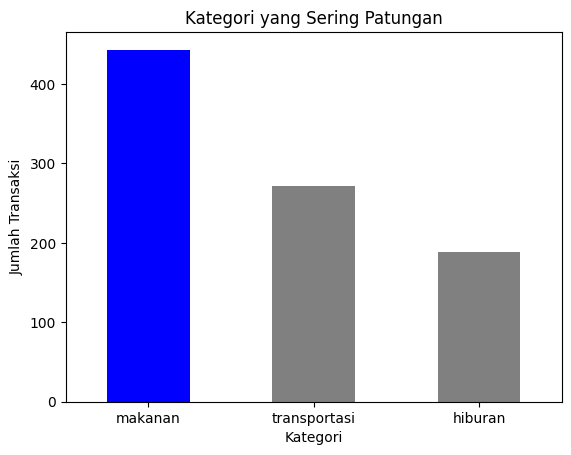

In [98]:
#Kategori yang sering patungan
split_category_counts = df_split[df_split['is_shared']==1]['category'].value_counts()

colors_split_category = ['blue' if i == split_category_counts.max() else 'gray' for i in split_category_counts.values]

split_category_counts.plot(kind='bar', color=colors_split_category)

plt.title("Kategori yang Sering Patungan")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=0)
plt.show()

**Insight:**
- Sebagian besar transaksi masih dilakukan secara individu, menunjukkan bahwa fitur patungan belum menjadi perilaku utama pengguna dalam seluruh aktivitas keuangan.
- Kategori makanan merupakan aktivitas yang paling sering dibagi, yang menunjukkan bahwa kegiatan seperti makan bersama menjadi use case utama dalam penggunaan fitur SplitMate.
- Karena kategori seperti tempat_tinggal atau tagihan tidak muncul dominan, dapat disimpulkan bahwa patungan lebih sering terjadi pada aktivitas non-rutin dibandingkan kebutuhan wajib.

###**Pertanyaan 2:** Bagaimana distribusi jumlah partisipan (num_people) dalam transaksi patungan, dan berapa jumlah partisipan yang paling dominan selama periode Januari 2021 hingga Desember 2024?

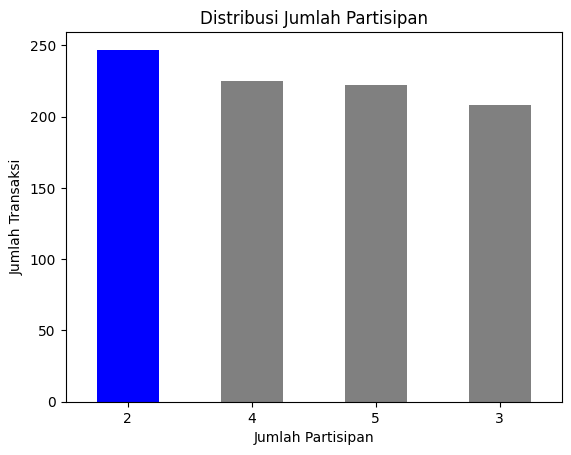

In [99]:
#Jumlah orang dalam patungan
num_people_counts = df_split[df_split['is_shared']==1]['num_people'].value_counts()

colors_split_num = ['blue' if v == num_people_counts.max() else 'gray' for v in num_people_counts]

num_people_counts.plot(kind='bar', color=colors_split_num)

plt.title("Distribusi Jumlah Partisipan")
plt.xlabel("Jumlah Partisipan")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=0)
plt.show()

**Insight:**
- Grafik menunjukkan bahwa transaksi dengan 2 partisipan memiliki jumlah paling tinggi dibandingkan jumlah partisipan lainnya.
- Meskipun demikian, perbedaan jumlah transaksi antara 2, 3, 4, dan 5 partisipan tidak terlalu signifikan, sehingga distribusi transaksi berdasarkan jumlah partisipan cenderung relatif merata.
- Hal ini menunjukkan bahwa transaksi bersama dilakukan baik dalam kelompok kecil maupun kelompok yang lebih besar, tanpa adanya dominasi yang sangat kuat pada satu jumlah partisipan tertentu.
- Selain itu, tingginya jumlah transaksi dengan lebih dari dua partisipan mengindikasikan bahwa aktivitas pembagian biaya (split payment) cukup sering dilakukan dalam konteks kelompok.

###**Pertanyaan 3:** Siapa saja pengguna dengan total hutang terbesar (Top 10) berdasarkan nilai transaksi patungan selama periode Januari 2021 hingga Desember 2024?

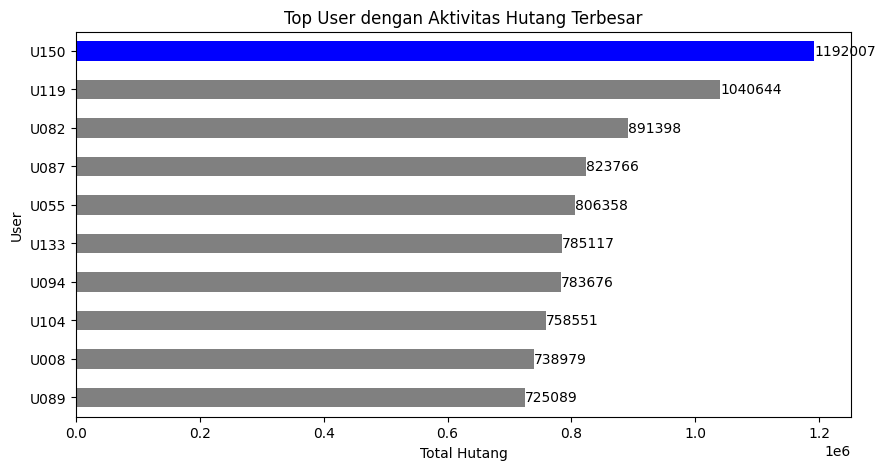

In [100]:
#Yang paling banyak hutang, top 10
debt_per_user = df_debt.groupby('from')['amount_idr'].sum().sort_values(ascending=False)
top_debt = debt_per_user.head(10)
sorted_debt = top_debt.sort_values()

colors_debt = ['blue' if v == sorted_debt.max() else 'gray' for v in sorted_debt]

ax = sorted_debt.plot(kind='barh', figsize=(10,5), color=colors_debt)

for i, v in enumerate(sorted_debt):
    ax.text(v, i, f"{int(v)}", va='center')

plt.title("Top User dengan Aktivitas Hutang Terbesar")
plt.xlabel("Total Hutang")
plt.ylabel("User")
plt.show()

**Insight:**
- Terlihat bahwa hutang terbesar tidak dimiliki oleh banyak orang, melainkan hanya oleh beberapa user saja. Sepuluh pengguna teratas ini menyumbang jumlah hutang yang cukup besar dibandingkan user lainnya, sehingga bisa dikatakan bahwa hutang terkonsentrasi pada kelompok kecil.
- User seperti U150, U119, dan U082 terlihat paling menonjol karena memiliki nilai hutang paling tinggi, bahkan ada yang mencapai lebih dari 1 juta. Nilai ini cukup jauh dibandingkan beberapa user lain di bawahnya, meskipun selisih antar peringkat tetap terlihat menurun secara bertahap.
- Dari kondisi ini, bisa disimpulkan bahwa kelompok Top 10 ini perlu mendapat perhatian lebih. Mereka berpotensi memberikan dampak besar terhadap total hutang secara keseluruhan, sehingga penting untuk memantau aktivitas dan pembayaran mereka agar risiko dapat dikendalikan.

###**Pertanyaan 4:** Siapa saja pengguna dengan total piutang terbesar (Top 10) berdasarkan transaksi patungan selama periode Januari 2021 hingga Desember 2024?

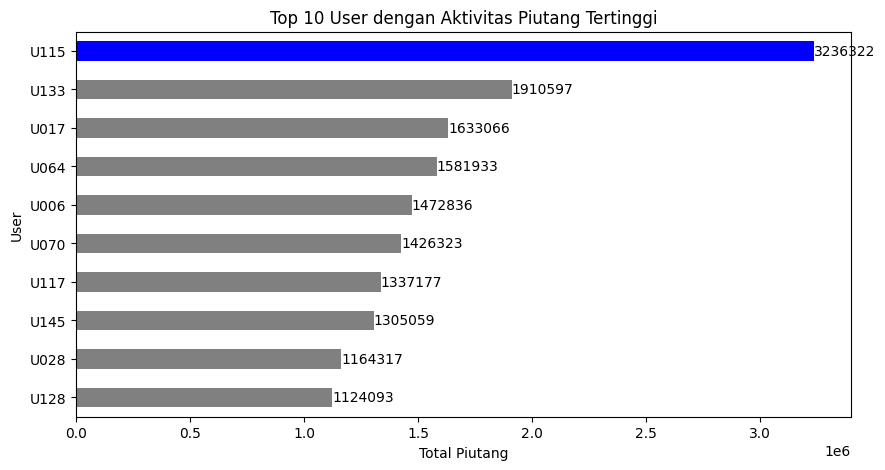

In [101]:
#Yang paling sering piutang
receivable = df_debt.groupby('to')['amount_idr'].sum().sort_values(ascending=False)

top_n = 10
top_receivable = receivable.head(top_n)
sorted_receivable = top_receivable.sort_values()

colors_receivable = ['blue' if v == sorted_receivable.max() else 'gray' for v in sorted_receivable]

ax = sorted_receivable.plot(kind='barh', figsize=(10,5), color=colors_receivable)

# Tambah label angka
for i, v in enumerate(sorted_receivable):
    ax.text(v, i, f"{int(v)}", va='center')

plt.title("Top 10 User dengan Aktivitas Piutang Tertinggi")
plt.xlabel("Total Piutang")
plt.ylabel("User")
plt.show()

**Insight:**
- Berdasarkan grafik Top 10 User dengan Aktivitas Piutang Tertinggi, user U115 memiliki total piutang paling besar dibandingkan user lainnya, dengan nilai mencapai sekitar 3.23 juta rupiah. Nilai ini terlihat jauh lebih tinggi dibandingkan posisi kedua dan seterusnya.
- Setelah U115, user dengan total piutang tertinggi berikutnya adalah U133, U017, dan U064 dengan total piutang berada pada kisaran 1.58-1.91 juta rupiah. Hal ini menunjukkan adanya perbedaan yang cukup signifikan antara user tertinggi dengan user lainnya.
- Selain itu, total piutang pada peringkat berikutnya cenderung menurun secara bertahap hingga kisaran sekitar 1.12-1.47 juta rupiah. Pola ini menunjukkan bahwa aktivitas piutang lebih terkonsentrasi pada beberapa user tertentu dibandingkan tersebar merata pada seluruh pengguna.
- Secara keseluruhan, hasil analisis mengindikasikan bahwa terdapat sejumlah user yang sangat aktif dalam melakukan transaksi piutang, baik karena frekuensi transaksi yang tinggi maupun karena nominal transaksi yang relatif besar dibandingkan user lainnya.

###**Pertanyaan 5:** Siapa saja pasangan pengguna dengan nilai hutang terbesar berdasarkan total transaksi patungan selama periode Januari 2021 hingga Desember 2024?

In [102]:
#Relasi hutang terbesar
debt_summary.sort_values(by='amount_idr', ascending=False).head(10)

,from,to,amount_idr
1020,U053,U070,671456.50
1986,U104,U070,671456.50
2086,U108,U145,609824.00
1695,U087,U145,609824.00
1726,U089,U115,543603.20
2661,U138,U115,541310.28
2550,U133,U051,454952.00
2390,U124,U051,454952.00
2299,U119,U149,395323.50
2893,U150,U149,395323.50


In [103]:
#Cek duplikasi
df_debt[df_debt.duplicated(
    subset=['from','to','amount_idr']
)]

,from,to,amount_idr


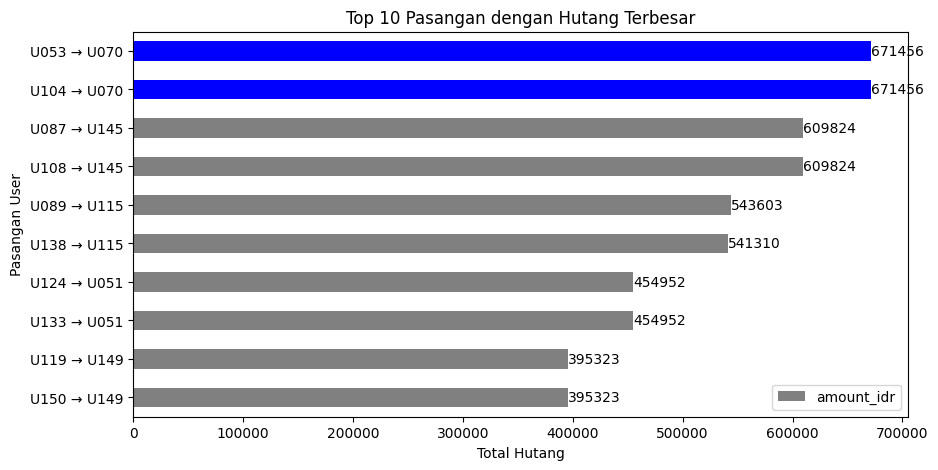

In [104]:
#Ambil top 10 pasangan teratas
top_pairs = debt_summary.sort_values(by='amount_idr', ascending=False).head(10)

top_pairs['pair'] = top_pairs['from'] + " → " + top_pairs['to']
top_pairs = top_pairs.sort_values(by='amount_idr')

colors_pairs = ['blue' if v == top_pairs['amount_idr'].max() else 'gray' for v in top_pairs['amount_idr']]

ax = top_pairs.plot(
    kind='barh',
    x='pair',
    y='amount_idr',
    figsize=(10,5),
    color=colors_pairs
)

for i, v in enumerate(top_pairs['amount_idr']):
    ax.text(v, i, f"{int(v)}", va='center')

plt.title("Top 10 Pasangan dengan Hutang Terbesar")
plt.xlabel("Total Hutang")
plt.ylabel("Pasangan User")
plt.show()

**Insight:**
- Berdasarkan analisis pasangan user dengan nilai piutang terbesar, terlihat bahwa beberapa user muncul berulang kali sebagai penerima piutang, seperti U070, U145, U115, U051, dan U149. Hal ini menunjukkan bahwa aktivitas piutang cenderung terkonsentrasi pada beberapa user tertentu.
- Pasangan dengan nilai piutang terbesar adalah transaksi dari U053 ke U070 dan dari U104 ke U070 dengan nilai masing-masing sekitar 671456 rupiah. Selain itu, pasangan menuju U145 dan U115 juga memiliki nilai piutang yang relatif tinggi dibandingkan pasangan lainnya.
- Pola ini menunjukkan bahwa terdapat beberapa user yang secara konsisten menerima pembayaran atau penggantian dana dari banyak user lain, sehingga membentuk relasi piutang yang dominan dalam dataset.
- Temuan ini juga sejalan dengan analisis sebelumnya, di mana user dengan total aktivitas piutang tertinggi cenderung muncul kembali dalam pasangan dengan nilai piutang terbesar. Hal tersebut mengindikasikan bahwa user tersebut kemungkinan sering menanggung pembayaran dalam transaksi kelompok atau melakukan transaksi dengan nominal relatif besar.

##**Conclusion**


Berdasarkan hasil analisis, dapat disimpulkan bahwa perilaku transaksi patungan pengguna masih belum menjadi aktivitas utama, karena sebagian besar transaksi dilakukan secara individu. Namun, ketika patungan terjadi, aktivitas tersebut didominasi oleh kategori yang bersifat sosial, seperti food, travel, dan entertainment yang menunjukkan bahwa penggunaan fitur patungan lebih banyak terjadi pada kegiatan bersama dibandingkan kebutuhan rutin. Selain itu, transaksi patungan selama periode Januari 2021 hingga Desember 2024 melibatkan jumlah partisipan yang relatif beragam, dengan jumlah partisipan paling dominan adalah 2 orang. Meskipun demikian, transaksi dengan 3 hingga 5 partisipan juga memiliki jumlah yang cukup tinggi, sehingga menunjukkan bahwa aktivitas pembagian biaya dilakukan baik dalam kelompok kecil maupun kelompok yang lebih besar.

Dari sisi aktivitas piutang, distribusi nilai piutang tidak tersebar secara merata pada seluruh pengguna, melainkan terkonsentrasi pada beberapa user tertentu. User seperti U115, U133, U017, dan U064 memiliki total piutang yang jauh lebih tinggi dibandingkan user lainnya. Hal ini menunjukkan bahwa terdapat sejumlah user yang lebih aktif dalam transaksi piutang, baik karena frekuensi transaksi yang tinggi maupun nominal transaksi yang relatif besar.

Selain itu, analisis pasangan user dengan nilai piutang terbesar menunjukkan bahwa beberapa user muncul berulang kali sebagai penerima piutang, seperti U070, U145, U115, U051, dan U149. Pola ini mengindikasikan bahwa terdapat user tertentu yang sering menerima pembayaran atau penggantian dana dari banyak user lain, sehingga membentuk relasi piutang yang dominan dalam dataset. Temuan tersebut juga menunjukkan adanya pola hubungan dalam transaksi patungan, di mana beberapa user cenderung berperan sebagai pihak yang lebih sering menanggung pembayaran terlebih dahulu sebelum menerima penggantian dari user lain.

Secara keseluruhan, hasil analisis menunjukkan bahwa pola transaksi patungan dipengaruhi oleh aktivitas sosial, distribusi jumlah partisipan, serta konsentrasi aktivitas piutang pada user tertentu. Oleh karena itu, pengelolaan transaksi patungan memerlukan sistem yang mampu mencatat pembagian biaya dan relasi piutang antar pengguna secara jelas, transparan, dan terstruktur.

## Simpan berkas dataset SplitMate

In [105]:
#Menyimpan berkas dataset SplitMate
df_split.to_csv("splitmate_dataset.csv", index=False)